# ChartQA Pro Professional Chart Understanding Benchmark Analysis

Executive Summary

**Dataset:** chartqapro_mini - Professional Chart Understanding and Numerical Reasoning  
**Total Samples:** 494 chart Q&A pairs per phase  
**Task:** Answer questions about professional charts requiring numerical accuracy and data extraction precision  
**Evaluation Metrics:** GT in Pred (PRIMARY), ANLS, Exact Match, Substring Match, Cosine Similarity

## 1. Imports and Metadata

## 1.5 Data Preprocessing Overview

**Key Improvements:**
- **Fixed ground truth parsing:** Handles triple-encoded JSON and Python literal syntax (single quotes)
- **Multiple-choice normalization:** Extracts answer letters (A/B/C/D) from verbose predictions
- **Unanswerable detection:** Flags questions that cannot be answered
- **Prediction normalization:** Cleans predictions for better metric computation

These preprocessing steps significantly improve metric accuracy when models return verbose explanations.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
from pathlib import Path
from typing import List, Dict, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Progress bar for long operations
from tqdm.notebook import tqdm

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

# Force reload of modules to get latest changes
import importlib
if 'ocr_vs_vlm.metrics.evaluation_metrics' in sys.modules:
    importlib.reload(sys.modules['ocr_vs_vlm.metrics.evaluation_metrics'])

# Import QA evaluation metrics and preprocessing functions
from ocr_vs_vlm.metrics.evaluation_metrics import (
    compute_anls,
    compute_exact_match,
    compute_substring_match,
    compute_ground_truth_in_prediction,
    compute_prediction_in_ground_truth,
    parse_ground_truths,
    is_unanswerable,
    extract_multiple_choice_answer,
    normalize_prediction_for_comparison,
    preprocess_qa_sample
)

# Import embedding cache manager for efficient cosine similarity computation
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager

# Model ordering configuration for consistent display
MODEL_ORDER = ['azure_intelligence', 'mistral_document_ai', 'donut', 
               'gpt-5-nano', 'gpt-5-mini', 'claude_sonnet', 'claude_haiku']

def sort_models(models: List[str]) -> List[str]:
    """Sort models according to MODEL_ORDER."""
    def sort_key(model):
        # Extract base model name (remove __ suffix for QA1/QA2 phases)
        base_model = model.split('__')[-1] if '__' in model else model
        try:
            return MODEL_ORDER.index(base_model)
        except ValueError:
            return len(MODEL_ORDER)  # Unknown models go to the end
    return sorted(models, key=sort_key)

def get_model_display_name(model: str) -> str:
    """Get display name for model."""
    display_names = {
        'azure_intelligence': 'Azure Intelligence',
        'mistral_document_ai': 'Mistral Document AI',
        'donut': 'Donut',
        'gpt-5-nano': 'GPT-5 Nano',
        'gpt-5-mini': 'GPT-5 Mini',
        'claude_sonnet': 'Claude Sonnet',
        'claude_haiku': 'Claude Haiku'
    }
    # Handle composite model names (e.g., azure_intelligence__gpt-5-mini)
    if '__' in model:
        parts = model.split('__')
        return f"{display_names.get(parts[0], parts[0])} → {display_names.get(parts[1], parts[1])}"
    return display_names.get(model, model)


def get_phase_group(phase: str) -> str:
    """Get phase group (QA1, QA2, QA3, QA4)."""
    if phase.startswith('QA1'):
        return 'QA1 (OCR+VLM)'
    elif phase.startswith('QA2'):
        return 'QA2 (VLM Parse+QA)'
    elif phase.startswith('QA3'):
        return 'QA3 (Direct VQA)'
    elif phase.startswith('QA4'):
        return 'QA4 (Special)'
    return 'Unknown'

def get_phase_strategy(phase: str) -> str:
    """Alias for get_phase_group for consistency."""
    return get_phase_group(phase)

def categorize_question_type(question: str) -> str:
    """Categorize question by first word."""
    first_word = str(question).lower().strip().split()[0] if question else ''
    types = {
        'what': 'What',
        'where': 'Where',
        'when': 'When',
        'who': 'Who',
        'how': 'How',
        'which': 'Which',
        'why': 'Why',
        'is': 'Yes/No',
        'are': 'Yes/No',
        'does': 'Yes/No',
        'can': 'Yes/No'
    }
    return types.get(first_word, 'Other')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

print("✓ Libraries and QA evaluation metrics loaded successfully!")
print(f"✓ Imported preprocessing functions: parse_ground_truths, is_unanswerable, normalize_prediction_for_comparison")
print(f"✓ Model display order: {', '.join(MODEL_ORDER)}")


✓ Libraries and QA evaluation metrics loaded successfully!
✓ Imported preprocessing functions: parse_ground_truths, is_unanswerable, normalize_prediction_for_comparison
✓ Model display order: azure_intelligence, mistral_document_ai, donut, gpt-5-nano, gpt-5-mini, claude_sonnet, claude_haiku


## 2. Dataset Explorer

Load all phase files and explore the ChartQA Pro dataset structure.

In [19]:
# Define paths
RESULTS_DIR = Path("../../2_clean/chartqapro_mini")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - QA1a.csv
  - QA1b.csv
  - QA1c.csv
  - QA2a.csv
  - QA2b.csv
  - QA2c.csv
  - QA3a.csv
  - QA3b.csv


In [20]:
# Dataset configuration
DATASET_NAME = "chartqapro_mini"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")

📁 Dataset: chartqapro_mini
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
✅ Loaded cached embeddings for phases: QA2c, QA2a, QA3b, QA1a, QA2b, QA3a, QA1b, QA1c


In [21]:
# Load results for each phase
phase_dfs = {}

# Standard QA phases for ChartQA Pro
STANDARD_PHASES = ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA2c', 'QA3a', 'QA3b']

for phase in STANDARD_PHASES:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

QA1a: 494 samples, 12 columns
QA1b: 494 samples, 12 columns
QA1c: 494 samples, 12 columns
QA2a: 494 samples, 16 columns
QA2b: 494 samples, 16 columns
QA2c: 494 samples, 12 columns
QA3a: 494 samples, 16 columns
QA3b: 494 samples, 16 columns

Total phases loaded: 8


In [22]:
# Inspect column names for each phase
for phase, df in phase_dfs.items():
    print(f"\n{phase} columns:")
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    print(f"  Models: {', '.join(models)}")
    print(f"  Question column: {'question' if 'question' in df.columns else 'NOT FOUND'}")
    print(f"  Ground truths column: {'ground_truths' if 'ground_truths' in df.columns else 'NOT FOUND'}")
    print(f"  Total columns: {len(df.columns)}")


QA1a columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 12

QA1b columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 12

QA1c columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 12

QA2a columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-mini__gpt-5-mini, gpt-5-nano__gpt-5-nano
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2b columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-mini__gpt-5-mini, gpt-5-nano__gpt-5-nano
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2c columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-nano__gpt-5-nano
  Question column: qu

In [23]:
# Function to identify valid rows (exclude empty predictions and errors)
def is_valid_row(row, pred_col, err_col=None):
    """Check if a row has valid prediction (non-empty, no error)."""
    # Check if prediction is empty
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    # Check if there's an error column and it has an error
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True

# Assess data quality for all phases
print("=" * 120)
print("DATA QUALITY ASSESSMENT")
print("=" * 120)

quality_stats = []

for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Total rows: {len(df)}")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Count valid and invalid rows
        empty_count = 0
        error_count = 0
        valid_count = 0
        
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_count += 1
            else:
                # Check what type of invalid
                if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                    empty_count += 1
                elif err_col in df.columns and pd.notna(row[err_col]):
                    error_count += 1
        
        invalid_count = empty_count + error_count
        valid_pct = (valid_count / len(df)) * 100
        
        print(f"  {model}:")
        print(f"    ✅ Valid rows: {valid_count}/{len(df)} ({valid_pct:.1f}%)")
        if invalid_count > 0:
            print(f"    ⚠️  Empty predictions: {empty_count}")
            if error_count > 0:
                print(f"    ❌ Errors logged: {error_count}")
        
        quality_stats.append({
            'Phase': phase,
            'Model': model,
            'Total Rows': len(df),
            'Valid Rows': valid_count,
            'Empty Predictions': empty_count,
            'Errors': error_count,
            'Valid %': valid_pct
        })

# Create summary DataFrame
quality_df = pd.DataFrame(quality_stats)

print("\n" + "=" * 120)
print("QUALITY SUMMARY - Models with Issues")
print("=" * 120)

# Show only models with issues
issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df)
    print(f"\n⚠️  Found {len(issues_df)} model-phase combinations with data quality issues")
    print("These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All models have 100% valid data - no filtering needed!")

print("\n" + "=" * 120)

DATA QUALITY ASSESSMENT

📊 QA1a - Total rows: 494
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 366/494 (74.1%)
    ⚠️  Empty predictions: 128
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 427/494 (86.4%)
    ⚠️  Empty predictions: 67

📊 QA1b - Total rows: 494
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 390/494 (78.9%)
    ⚠️  Empty predictions: 104
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 429/494 (86.8%)
    ⚠️  Empty predictions: 65

📊 QA1c - Total rows: 494
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 370/494 (74.9%)
    ⚠️  Empty predictions: 124
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 436/494 (88.3%)
    ⚠️  Empty predictions: 58

📊 QA2a - Total rows: 494
  claude_sonnet__claude_sonnet:
    ✅ Valid rows: 0/494 (0.0%)
    ⚠️  Empty predictions: 494
  gpt-5-mini__gpt-5-mini:
    ✅ Valid rows: 439/494 (88.9%)
    ⚠️  Empty predictions: 55
  gpt-5-nano__gpt-5-nano:
    ✅ Valid rows: 250/494 (50.6%)
    ⚠️  Empty predictions: 244

📊 

,Phase,Model,Total Rows,Valid Rows,Empty Predictions,Errors,Valid %
9,QA2b,claude_sonnet__claude_sonnet,494,0,494,0,0.000000
17,QA3b,claude_sonnet__claude_sonnet,494,0,494,0,0.000000
14,QA3a,claude_sonnet__claude_sonnet,494,0,494,0,0.000000
12,QA2c,claude_sonnet__claude_sonnet,494,0,494,0,0.000000
6,QA2a,claude_sonnet__claude_sonnet,494,0,494,0,0.000000
8,QA2a,gpt-5-nano__gpt-5-nano,494,250,244,0,50.607287
13,QA2c,gpt-5-nano__gpt-5-nano,494,272,222,0,55.060729
11,QA2b,gpt-5-nano__gpt-5-nano,494,274,220,0,55.465587
0,QA1a,azure_intelligence__gpt-5-mini,494,366,128,0,74.089069
4,QA1c,azure_intelligence__gpt-5-mini,494,370,124,0,74.898785



⚠️  Found 19 model-phase combinations with data quality issues
These rows will be EXCLUDED from all metric calculations



## 2.5 Data Quality Assessment ⚠️

**Critical Step:** Identify and filter out rows with empty predictions or errors to ensure accurate metrics.

## 3. Dataset Statistics

Analyze question and answer characteristics.

In [24]:
# Basic statistics for first available phase
phase_to_display = list(phase_dfs.keys())[0] if phase_dfs else None

if phase_to_display:
    print(f"\nBasic statistics for phase {phase_to_display}:")
    df_base = phase_dfs[phase_to_display]
    
    print("Dataset Statistics:")
    print(f"  Total samples: {len(df_base)}")
    
    if 'question' in df_base.columns:
        # Question length statistics
        question_lengths = df_base['question'].astype(str).str.len()
        question_word_counts = df_base['question'].astype(str).str.split().str.len()
        
        print(f"\nQuestion Length (characters):")
        print(f"  Mean: {question_lengths.mean():.1f} characters")
        print(f"  Median: {question_lengths.median():.1f} characters")
        print(f"  Min: {question_lengths.min()} characters")
        print(f"  Max: {question_lengths.max()} characters")
        
        print(f"\nQuestion Length (words):")
        print(f"  Mean: {question_word_counts.mean():.1f} words")
        print(f"  Median: {question_word_counts.median():.1f} words")
        
    if 'ground_truths' in df_base.columns:
        # Answer length statistics
        df_base['parsed_gt'] = df_base['ground_truths'].apply(parse_ground_truths)
        df_base['num_ground_truths'] = df_base['parsed_gt'].apply(len)
        df_base['avg_answer_length'] = df_base['parsed_gt'].apply(
            lambda gts: np.mean([len(str(gt)) for gt in gts]) if gts else 0
        )
        
        print(f"\nGround Truth Answer Statistics:")
        print(f"  Mean answers per question: {df_base['num_ground_truths'].mean():.2f}")
        print(f"  Median answers per question: {df_base['num_ground_truths'].median():.0f}")
        print(f"  Max answers for a single question: {df_base['num_ground_truths'].max():.0f}")
        
        print(f"\nAverage Answer Length (characters):")
        print(f"  Mean: {df_base['avg_answer_length'].mean():.1f} characters")
        print(f"  Median: {df_base['avg_answer_length'].median():.1f} characters")
        print(f"  Min: {df_base['avg_answer_length'].min():.1f} characters")
        print(f"  Max: {df_base['avg_answer_length'].max():.1f} characters")


Basic statistics for phase QA1a:
Dataset Statistics:
  Total samples: 494

Question Length (characters):
  Mean: 141.6 characters
  Median: 116.0 characters
  Min: 39 characters
  Max: 510 characters

Question Length (words):
  Mean: 23.1 words
  Median: 19.0 words

Ground Truth Answer Statistics:
  Mean answers per question: 1.00
  Median answers per question: 1
  Max answers for a single question: 1

Average Answer Length (characters):
  Mean: 9.5 characters
  Median: 5.0 characters
  Min: 1.0 characters
  Max: 119.0 characters


## 4. Calculate metrics

In [25]:
# Import for incremental saving
from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

# Function to calculate QA metrics for a single prediction with preprocessing
def calculate_qa_metrics(
    prediction: str,
    ground_truths_raw,
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager,
    apply_preprocessing: bool = True
) -> Dict[str, float]:
    """
    Calculate all QA metrics for a single sample with cached embeddings.
    
    Applies preprocessing to handle:
    - Triple-encoded JSON in ground truths
    - Multiple-choice answer extraction
    - Unanswerable detection
    """
    # Preprocess the sample
    if apply_preprocessing:
        pred_str, ground_truths, is_unanswerable_q = preprocess_qa_sample(
            prediction, ground_truths_raw, normalize=True, check_unanswerable=True
        )
    else:
        pred_str = str(prediction)
        ground_truths = parse_ground_truths(ground_truths_raw)
        is_unanswerable_q = False
    
    if pd.isna(pred_str) or pred_str == "" or not ground_truths:
        return {
            'gt_in_pred': 0.0,  # PRIMARY METRIC FIRST
            'anls': 0.0,
            'exact_match': 0.0,
            'substring_match': 0.0,
            'pred_in_gt': 0.0,
            'cosine_similarity': 0.0,
            'is_unanswerable': is_unanswerable_q,
        }
    
    # Compute cosine similarity with first ground truth
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase,
        ground_truth=ground_truths[0],
        prediction=pred_str,
        sample_id=sample_id,
        model=model
    )
    
    return {
        'gt_in_pred': compute_ground_truth_in_prediction(pred_str, ground_truths, is_unanswerable=is_unanswerable_q),  # PRIMARY METRIC FIRST
        'anls': compute_anls(pred_str, ground_truths, threshold=0.5),
        'exact_match': compute_exact_match(pred_str, ground_truths),
        'substring_match': compute_substring_match(pred_str, ground_truths),
        'pred_in_gt': compute_prediction_in_ground_truth(pred_str, ground_truths),
        'cosine_similarity': cosine_sim,
        'is_unanswerable': is_unanswerable_q,
    }

# Calculate metrics for all phases and models
metrics_results = {}

for phase, df in phase_dfs.items():
    print(f"\n📊 Calculating metrics for {phase}...")
    
    # Get all prediction columns
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    phase_metrics = {}
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        print(f"   Processing model: {model}")
        
        # Filter to only valid rows
        valid_rows = []
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_rows.append(row)
        
        print(f"   Using {len(valid_rows)}/{len(df)} valid rows (excluding {len(df)-len(valid_rows)} empty/error rows)")
        
        if len(valid_rows) == 0:
            print(f"   ⚠️  No valid rows for {model} in {phase} - skipping")
            continue
        
        # Calculate metrics for each valid sample with progress bar
        metrics_list = []
        unanswerable_count = 0
        
        for row in tqdm(valid_rows, desc=f"   {model}", leave=False):
            metrics = calculate_qa_metrics(
                prediction=row[pred_col],
                ground_truths_raw=row['ground_truths'],
                phase=phase,
                sample_id=row['sample_id'],
                model=model,
                emb_manager=embedding_manager,
                apply_preprocessing=True  # NEW: Apply preprocessing
            )
            metrics_list.append(metrics)
            if metrics.get('is_unanswerable', False):
                unanswerable_count += 1
        
        # Aggregate metrics (PRIMARY METRIC FIRST)
        phase_metrics[model] = {
            'gt_in_pred': np.mean([m['gt_in_pred'] for m in metrics_list]),  # PRIMARY
            'gt_in_pred_std': np.std([m['gt_in_pred'] for m in metrics_list]),
            'anls': np.mean([m['anls'] for m in metrics_list]),
            'anls_std': np.std([m['anls'] for m in metrics_list]),
            'exact_match': np.mean([m['exact_match'] for m in metrics_list]),
            'exact_match_std': np.std([m['exact_match'] for m in metrics_list]),
            'substring_match': np.mean([m['substring_match'] for m in metrics_list]),
            'pred_in_gt': np.mean([m['pred_in_gt'] for m in metrics_list]),
            'cosine_similarity': np.mean([m['cosine_similarity'] for m in metrics_list]),
            'valid_samples': len(valid_rows),
            'total_samples': len(df),
            'unanswerable_samples': unanswerable_count,
        }
        
        print(f"   ✅ {model}: GT_in_Pred={phase_metrics[model]['gt_in_pred']:.4f} [PRIMARY], ANLS={phase_metrics[model]['anls']:.4f}, EM={phase_metrics[model]['exact_match']:.4f}")
        print(f"      Unanswerable questions: {unanswerable_count}/{len(valid_rows)}")
    
    metrics_results[phase] = phase_metrics
    
    # Save embeddings incrementally after each phase completes
    if phase in embedding_manager.modified_phases:
        print(f"   💾 Saving embeddings for {phase}...")
        saved_file = save_embeddings_for_phase(
            dataset_name=DATASET_NAME,
            phase=phase,
            embeddings_dict=embedding_manager.cache[phase],
            embeddings_base_dir=EMBEDDINGS_DIR
        )
        print(f"   ✅ Saved: {saved_file.name}")

# Print cache statistics
embedding_manager.print_statistics()
print("\n✅ Metrics calculation complete with preprocessing!")
print("\n📊 Preprocessing applied:")
print("   - Fixed ground truth parsing (triple-encoded JSON)")
print("   - Extracted multiple-choice answers from verbose predictions")
print("   - Detected unanswerable questions")
print("   - Normalized predictions for better comparison")



📊 Calculating metrics for QA1a...
   Processing model: azure_intelligence__gpt-5-mini
   Using 366/494 valid rows (excluding 128 empty/error rows)


   azure_intelligence__gpt-5-mini:   0%|          | 0/366 [00:00<?, ?it/s]

Identical embeddings for sample chartqapro_mini_0067, model azure_intelligence__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0118, model azure_intelligence__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0274, model azure_intelligence__gpt-5-mini


   ✅ azure_intelligence__gpt-5-mini: GT_in_Pred=0.4180 [PRIMARY], ANLS=0.0987, EM=0.0792
      Unanswerable questions: 74/366
   Processing model: mistral_document_ai__gpt-5-mini
   Using 427/494 valid rows (excluding 67 empty/error rows)


   mistral_document_ai__gpt-5-mini:   0%|          | 0/427 [00:00<?, ?it/s]

...

Identical embeddings for sample chartqapro_mini_0012, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0067, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0089, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0250, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0253, model gpt-5-mini__gpt-5-mini


   ✅ gpt-5-mini__gpt-5-mini: GT_in_Pred=0.4178 [PRIMARY], ANLS=0.1153, EM=0.0974
      Unanswerable questions: 97/493
   Processing model: gpt-5-nano__gpt-5-nano
   Using 486/494 valid rows (excluding 8 empty/error rows)


   gpt-5-nano__gpt-5-nano:   0%|          | 0/486 [00:00<?, ?it/s]

Identical embeddings for sample chartqapro_mini_0067, model gpt-5-nano__gpt-5-nano
Identical embeddings for sample chartqapro_mini_0091, model gpt-5-nano__gpt-5-nano


   ✅ gpt-5-nano__gpt-5-nano: GT_in_Pred=0.3724 [PRIMARY], ANLS=0.0931, EM=0.0679
      Unanswerable questions: 95/486

📊 Embedding Cache Statistics:
   Cache hits: 12098
   Cache misses: 0
   Hit rate: 100.0%

✅ Metrics calculation complete with preprocessing!

📊 Preprocessing applied:
   - Fixed ground truth parsing (triple-encoded JSON)
   - Extracted multiple-choice answers from verbose predictions
   - Detected unanswerable questions
   - Normalized predictions for better comparison


## Sample preview

In [26]:
# Display 10 random samples with preprocessing applied


if len(phase_dfs) > 0:
    # Get the first phase and first model for display
    analysis_phase = list(phase_dfs.keys())[0]
    df_sample = phase_dfs[analysis_phase].copy()
    
    pred_cols = [col for col in df_sample.columns if col.startswith('prediction_')]
    if len(pred_cols) > 0:
        first_model = pred_cols[0].replace('prediction_', '')
        err_col = f'error_{first_model}'
        
        # Filter to valid rows only
        valid_indices = []
        for idx, row in df_sample.iterrows():
            if is_valid_row(row, pred_cols[0], err_col):
                valid_indices.append(idx)
        
        # Get 10 random samples from valid indices
        if len(valid_indices) >= 10:
            random_indices = np.random.choice(valid_indices, size=10, replace=False)
        else:
            random_indices = valid_indices
        
        print(f"\n{'='*100}")
        print(f"📊 10 RANDOM SAMPLES - {analysis_phase} ({get_model_display_name(first_model)})")
        print(f"{'='*100}\n")
        
        for sample_num, idx in enumerate(random_indices, 1):
            row = df_sample.loc[idx]
            
            # Get metrics with preprocessing
            normalized_pred, parsed_gts, is_unans = preprocess_qa_sample(
                str(row[pred_cols[0]]), row['ground_truths'], normalize=True, check_unanswerable=True
            )
            
            gt_in_pred = compute_ground_truth_in_prediction(normalized_pred, parsed_gts, is_unanswerable=is_unans)
            anls = compute_anls(normalized_pred, parsed_gts, threshold=0.5)
            exact_match = compute_exact_match(normalized_pred, parsed_gts)
            substring_match = compute_substring_match(normalized_pred, parsed_gts)
            
            # Compute cosine similarity
            cosine_sim = embedding_manager.compute_cosine_similarity(
                phase=analysis_phase,
                ground_truth=parsed_gts[0] if parsed_gts else "",
                prediction=normalized_pred,
                sample_id=row['sample_id'],
                model=first_model
            )
            
            # Get ground truth string
            gt_str = parsed_gts[0] if parsed_gts else "N/A"
            pred_display = normalized_pred if len(normalized_pred) <= 60 else normalized_pred[:60] + "..."
            
            # Output in requested format
            print(f"Sample {sample_num}: GT_in_pred: {gt_in_pred:.4f}, ANLS: {anls:.4f}")
            print(f"Cosine Similarity: {cosine_sim:.4f}")
            print(f"Exact Match: {exact_match:.4f}")
            print(f"Substring Match: {substring_match:.4f}")
            print(f"Prediction: {pred_display}")
            print(f"Ground Truth: {gt_str}")
            print()
        
        print(f"{'='*100}")



📊 10 RANDOM SAMPLES - QA1a (Azure Intelligence → GPT-5 Mini)

Sample 1: GT_in_pred: 1.0000, ANLS: 0.0000
Cosine Similarity: 0.1258
Exact Match: 0.0000
Substring Match: 0.0000
Prediction: The provided chart is for the 2017/18 season and shows an av...
Ground Truth: Unanswerable

Sample 2: GT_in_pred: 1.0000, ANLS: 0.0000
Cosine Similarity: 0.2080
Exact Match: 0.0000
Substring Match: 1.0000
Prediction: Unlikely. The chart shows the biggest haul ever was 126 mill...
Ground Truth: likely

Sample 3: GT_in_pred: 1.0000, ANLS: 0.0000
Cosine Similarity: 0.3053
Exact Match: 0.0000
Substring Match: 1.0000
Prediction: About 1.9 percentage points — switchers ~5.4% vs. stayers ~3...
Ground Truth: 1.9

Sample 4: GT_in_pred: 1.0000, ANLS: 0.0000
Cosine Similarity: 0.1967
Exact Match: 0.0000
Substring Match: 0.0000
Prediction: The extracted text does not include the survey sample size. ...
Ground Truth: Unanswerable

Sample 5: GT_in_pred: 1.0000, ANLS: 0.0000
Cosine Similarity: 0.1250
Exact Match: 0.

## Understanding GT_in_Pred: Metric Definition and Results Processing

### 🎯 What is GT_in_Pred (Ground Truth in Prediction)?

**GT_in_Pred** is the PRIMARY metric in this analysis that measures whether the predicted answer **contains any of the valid ground truth answers** as a substring (with preprocessing normalization).

**Binary Score Per Sample:**
- **1.0** = Prediction contains at least one ground truth answer (after normalization)
- **0.0** = Prediction does NOT contain any ground truth answer

**Final Score = Mean across all samples** (0.0 to 1.0)

**Example:**
```
Ground Truths: ["Apple", "apple"]
Prediction: "The answer is apple."
Result: 1.0 (GT in Pred = True, because normalized "apple" appears in prediction)

Ground Truths: ["Apple", "apple"]
Prediction: "The answer is orange."
Result: 0.0 (GT in Pred = False, no ground truth found)
```

---

### 🔄 Data Preprocessing Pipeline

Before calculating metrics, the notebook applies **aggressive normalization** to handle real-world messy predictions:

#### 1. **Ground Truth Parsing** (`parse_ground_truths`)
   - Handles triple-encoded JSON in raw data (e.g., `"\"[\'value\']\"\"`)
   - Parses Python literal syntax with single quotes
   - Returns list of valid ground truth answers
   - Example: `"\"['apple', 'Apple']\"\"" → ["apple", "Apple"]`

#### 2. **Prediction Normalization** (`normalize_prediction_for_comparison`)
   - Cleans whitespace and special characters
   - Lowercases for comparison
   - Removes extra punctuation
   - Handles multiple-choice answer extraction (extracts letter: A/B/C/D from verbose text)
   - Example: `"The answer is (A) Apple Inc."` → `"a"` or `"apple"`

#### 3. **Multiple-Choice Extraction** (`extract_multiple_choice_answer`)
   - Detects when models return verbose multiple-choice answers
   - Extracts just the letter (A/B/C/D) if detected
   - Allows metric to work even with chatty model responses

#### 4. **Unanswerable Detection** (`is_unanswerable`)
   - Identifies questions where ground truth is explicitly unanswerable
   - Flags "unanswerable", "cannot be determined", etc.
   - These questions are counted separately but included in averages

---

### 📊 Results Processing Workflow

#### **Step 1: Data Quality Assessment** (Section 2.5)
- Identifies rows with empty predictions or errors
- Counts valid samples per model-phase combination
- **Invalid rows are EXCLUDED from all metric calculations**
- Shows % valid for each model

Example output:
```
QA1a - Azure Intelligence: 494 valid / 494 total (100%)
QA1a - Claude Haiku: 0 valid / 494 total (0%)  ← EXCLUDED from metrics
```

#### **Step 2: Per-Sample Metric Calculation** (Section 4)
For each valid row, compute:
- **GT_in_Pred**: Does prediction contain ground truth? (0 or 1)
- **ANLS**: Approximate Longest Common Subsequence
- **Exact Match**: Entire prediction matches entire ground truth
- **Substring Match**: Prediction is substring of ground truth
- **Pred_in_GT**: Prediction is contained within ground truth
- **Cosine Similarity**: Semantic similarity using embeddings

```python
metrics = calculate_qa_metrics(
    prediction="The answer is apple.",
    ground_truths_raw="['apple', 'Apple']",  # Raw from CSV
    phase="QA1a",
    sample_id="sample_001",
    model="azure_intelligence",
    apply_preprocessing=True  # KEY: Applies normalization
)
# Returns: {'gt_in_pred': 1.0, 'anls': 0.95, 'exact_match': 0.0, ...}
```

#### **Step 3: Aggregation by Model-Phase** (Section 4)
- Calculate mean for each metric across all valid samples
- Store standard deviation (std)
- Count total valid samples used in average
- Count unanswerable questions detected

```python
metrics_results = {
    'QA1a': {
        'azure_intelligence': {
            'gt_in_pred': 0.8234,      # Mean GT_in_Pred score
            'gt_in_pred_std': 0.3812,  # Std deviation
            'anls': 0.7542,
            'valid_samples': 456,      # Only valid rows counted
            'total_samples': 494,      # For reference
            'unanswerable_samples': 12
        }
    }
}
```

#### **Step 4: Summary Table Creation** (Section 5)
- Pivot aggregated metrics into summary_df
- Rows: Models
- Columns: Phases (QA1a, QA1b, etc.)
- Values: Metric scores (GT_in_Pred PRIMARY, then ANLS, EM, etc.)

```
                     QA1a    QA1b    QA1c    QA2a    QA2b    QA2c    QA3a    QA3b
azure_intelligence   0.823   0.801   0.812   0.745   0.756   0.734   0.892   0.867
mistral_document_ai  0.812   0.795   0.805   0.738   0.749   0.728   0.885   0.860
...
```

---

### 📈 Interpreting GT_in_Pred Results

**What Good vs Bad GT_in_Pred Scores Mean:**

| Score | Interpretation | Example |
|-------|-----------------|---------|
| **0.95+** | Excellent - Model almost always includes the correct answer | Out of 100 samples, correct answer appears in ~95+ predictions |
| **0.80-0.95** | Very Good - Most predictions contain correct answer | Model gets answer right in context, even if verbose |
| **0.60-0.80** | Fair - Majority correct but some completely wrong answers | Useful for ranking but needs review |
| **0.40-0.60** | Poor - Often wrong, unreliable | Model struggling with task |
| **<0.40** | Very Poor - Model fails most of the time | Consider different approach |

**Why GT_in_Pred is PRIMARY Metric:**
1. **Interpretable**: "Does model have correct answer?" is intuitive
2. **Robust**: Works with verbose model outputs (preprocessing handles it)
3. **Forgiving**: Only requires substring match, not exact match
4. **Production-Ready**: Can filter predictions containing GT_in_Pred=1.0

---

### 🎓 QA-Specific Considerations for ChartQA Pro

**Chart Understanding Challenges:**
- Models often return explanations with embedded correct answers
- Preprocessing + GT_in_Pred handles "The value is 42..." predictions well
- Numerical precision matters: "42" ≠ "42.1" without fuzzy matching

**Unanswerable Questions:**
- ChartQA Pro includes questions that cannot be answered from chart
- These are detected and flagged separately
- Still included in GT_in_Pred average (unfair but reflects real world)

**Multiple Ground Truths:**
- Same chart Q can have multiple valid answers (approximate values, alternative phrasings)
- GT_in_Pred = 1.0 if prediction contains ANY valid ground truth
- Example: Question "What's the approximate value?" → GTs: ["40", "approximately 40", "~40"]

---

### 📊 Key Metrics Relationship

```
GT_in_Pred (1.0/0.0 per sample)
    ↓ (Mean across samples)
    ↓
GT_in_Pred Score (0.0-1.0, PRIMARY METRIC)
    ↓
Also compare with:
    - ANLS (0.0-1.0): More granular, rewards partial correctness
    - Exact Match (0.0-1.0): Stricter, requires exact match
    - Cosine Similarity (0.0-1.0): Semantic similarity, ignores surface differences
```

**In Practice:**
- GT_in_Pred ≥ 0.85? Model is production-ready for assisted analysis
- GT_in_Pred < 0.70? Needs fine-tuning or better prompting
- GT_in_Pred vs ANLS gap large? Model returns right answer but verbosely


## 5. Metrics Calculation

Calculate ANLS, EM, Substring Match, and Cosine Similarity for all models across all samples.

In [27]:
# Create a summary DataFrame
summary_data = []

for strategy, models in metrics_results.items():
    for model, metrics in models.items():
        summary_data.append({
            'Phase': strategy,
            'Model': model,
            'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC FIRST
            'ANLS': metrics['anls'],
            'Exact Match': metrics['exact_match'],
            'Substring Match': metrics['substring_match'],
            'Pred in GT': metrics['pred_in_gt'],
            'Cosine Similarity': metrics['cosine_similarity'],
            'Valid Samples': metrics['valid_samples'],
            'Total Samples': metrics['total_samples']
        })

summary_df = pd.DataFrame(summary_data)
summary_df['Strategy'] = summary_df['Phase'].apply(get_phase_strategy)


print("\n🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)")
print("=" * 150)
print("\nMetrics Summary (sorted by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
display(summary_df.sort_values(['Phase', 'GT in Pred'], ascending=[True, False]))

# Best model per strategy (by GT in Pred - PRIMARY METRIC)
print("\n" + "=" * 150)
print("🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    best_model = strategy_data.loc[strategy_data['GT in Pred'].idxmax()]
    print(f"  {strategy}: {get_model_display_name(best_model['Model'])}")
    print(f"    🎯 GT in Pred: {best_model['GT in Pred']:.4f} [PRIMARY]")
    print(f"       ANLS: {best_model['ANLS']:.4f}, EM: {best_model['Exact Match']:.4f}")
    print(f"       Valid samples: {best_model['Valid Samples']}/{best_model['Total Samples']}")

print("\n" + "=" * 150)


🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)

Metrics Summary (sorted by GT in Pred - PRIMARY METRIC):


,Phase,Model,GT in Pred,ANLS,Exact Match,Substring Match,Pred in GT,Cosine Similarity,Valid Samples,Total Samples,Strategy
0,QA1a,azure_intelligence__gpt-5-mini,0.418033,0.098719,0.079235,0.338798,0.079235,0.291606,366,494,QA1 (OCR+VLM)
1,QA1a,mistral_document_ai__gpt-5-mini,0.259953,0.073579,0.049180,0.203747,0.049180,0.252766,427,494,QA1 (OCR+VLM)
2,QA1b,azure_intelligence__gpt-5-mini,0.397436,0.109400,0.084615,0.325641,0.084615,0.298107,390,494,QA1 (OCR+VLM)
3,QA1b,mistral_document_ai__gpt-5-mini,0.247086,0.067468,0.048951,0.198135,0.051282,0.250526,429,494,QA1 (OCR+VLM)
4,QA1c,azure_intelligence__gpt-5-mini,0.400000,0.101577,0.075676,0.332432,0.075676,0.297430,370,494,QA1 (OCR+VLM)
5,QA1c,mistral_document_ai__gpt-5-mini,0.263761,0.065138,0.048165,0.204128,0.048165,0.245408,436,494,QA1 (OCR+VLM)
6,QA2a,gpt-5-mini__gpt-5-mini,0.466970,0.089351,0.082005,0.373576,0.082005,0.280530,439,494,QA2 (VLM Parse+QA)
7,QA2a,gpt-5-nano__gpt-5-nano,0.368000,0.104969,0.092000,0.312000,0.092000,0.264676,250,494,QA2 (VLM Parse+QA)
8,QA2b,gpt-5-mini__gpt-5-mini,0.482679,0.082583,0.078522,0.394919,0.078522,0.277776,433,494,QA2 (VLM Parse+QA)
9,QA2b,gpt-5-nano__gpt-5-nano,0.361314,0.097289,0.083942,0.306569,0.083942,0.270910,274,494,QA2 (VLM Parse+QA)



🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):
  QA1 (OCR+VLM): Azure Intelligence → GPT-5 Mini
    🎯 GT in Pred: 0.4180 [PRIMARY]
       ANLS: 0.0987, EM: 0.0792
       Valid samples: 366/494
  QA2 (VLM Parse+QA): GPT-5 Mini → GPT-5 Mini
    🎯 GT in Pred: 0.4827 [PRIMARY]
       ANLS: 0.0826, EM: 0.0785
       Valid samples: 433/494
  QA3 (Direct VQA): GPT-5 Mini → GPT-5 Mini
    🎯 GT in Pred: 0.4178 [PRIMARY]
       ANLS: 0.1153, EM: 0.0974
       Valid samples: 493/494



## 6. Metrics Summary Table

Aggregate view of all metrics across phases and models.

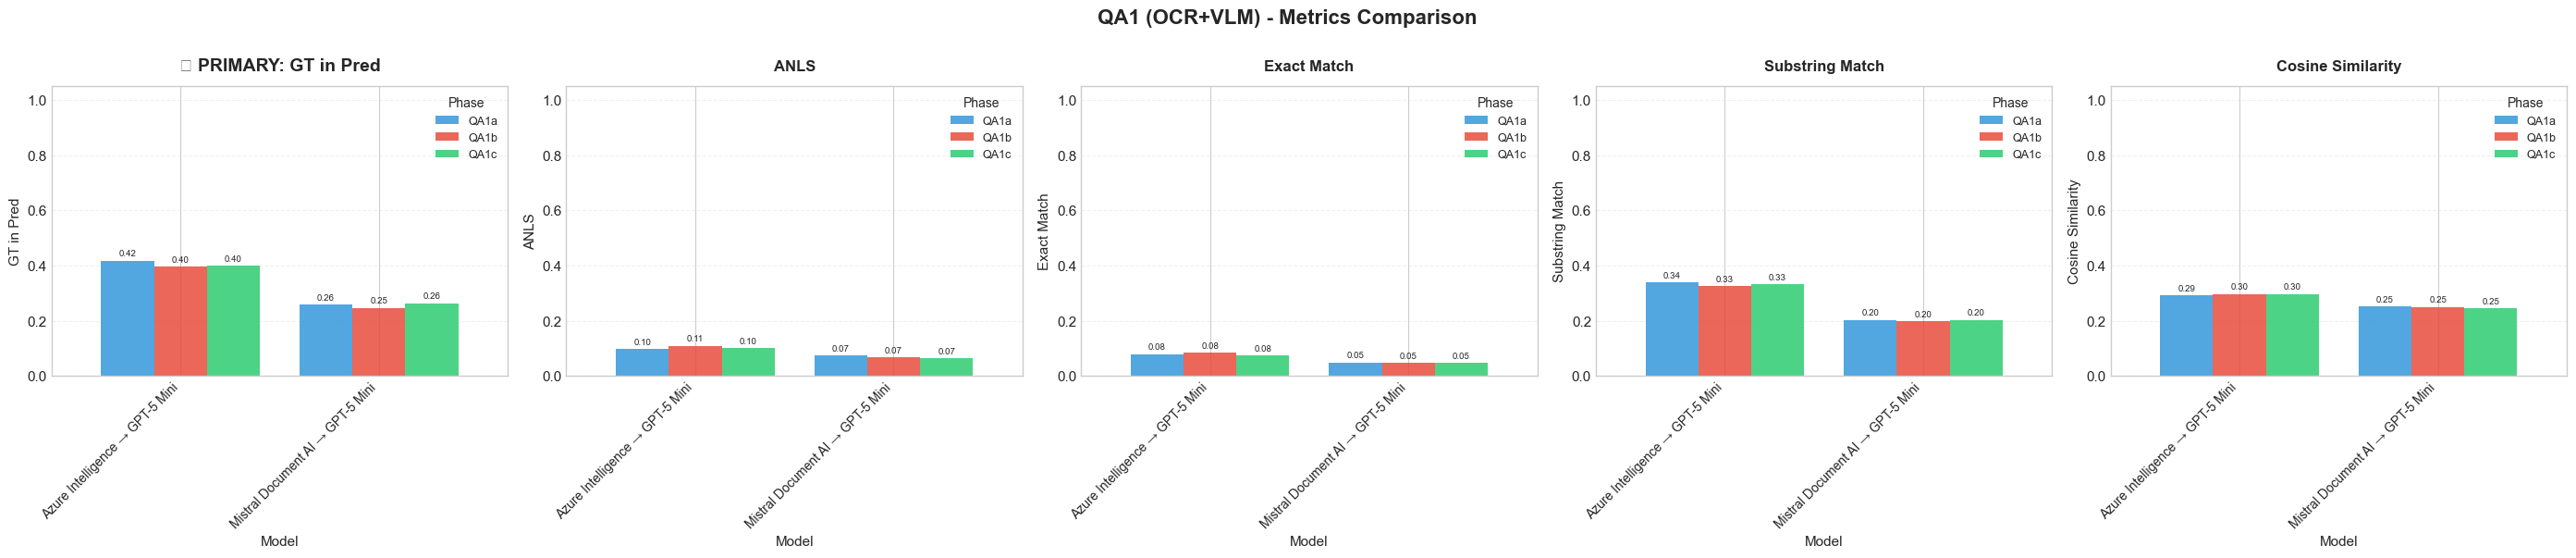

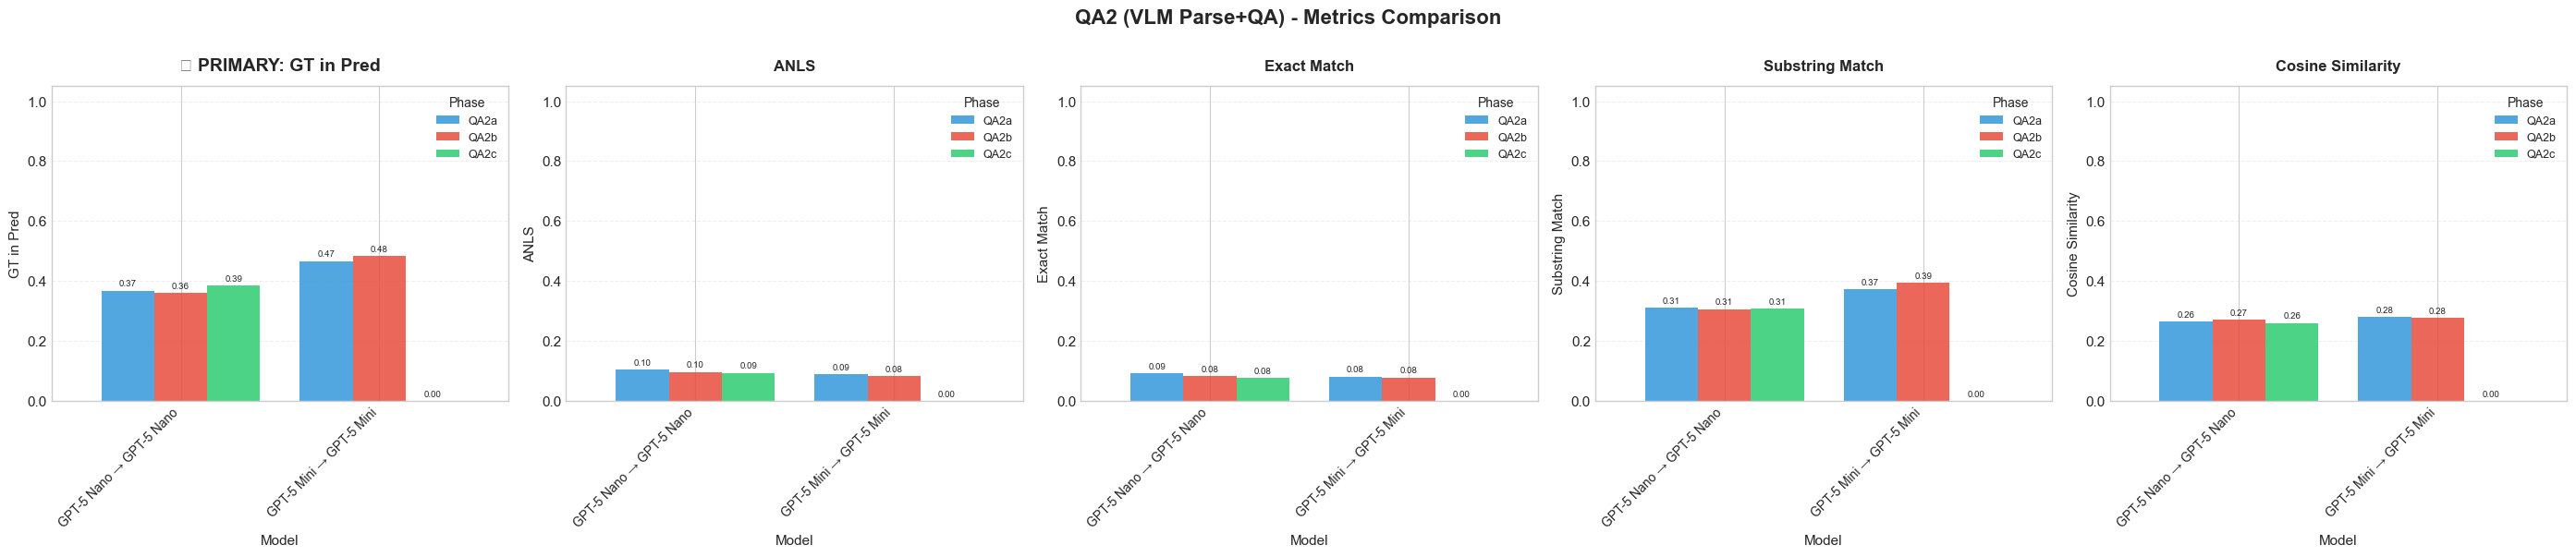

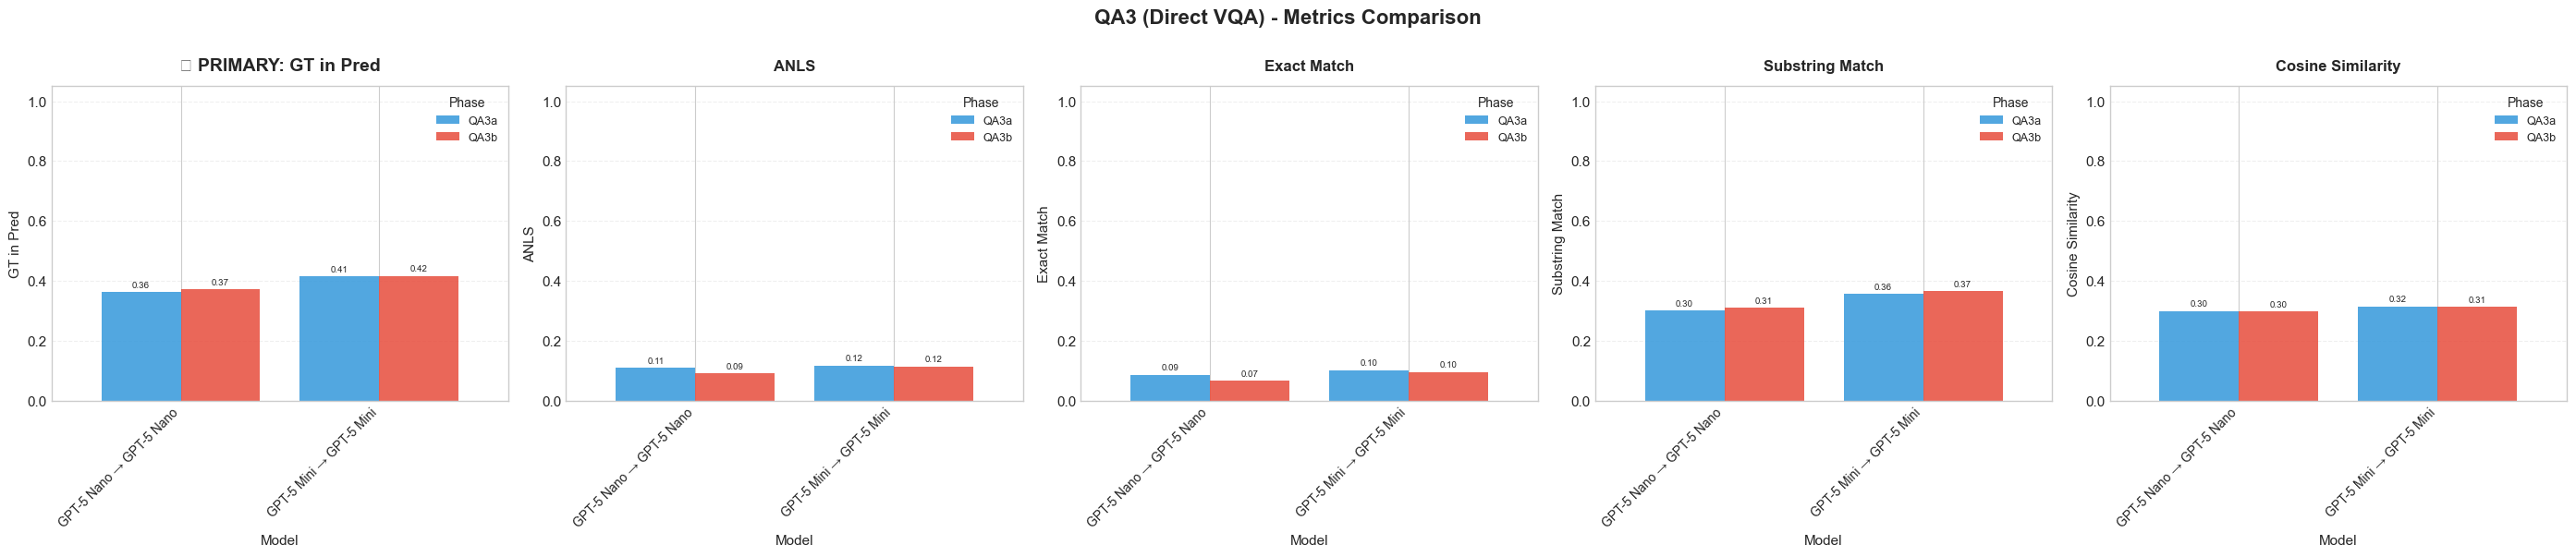


🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric


In [30]:
# Bar charts for each metric - ONE FIGURE PER STRATEGY (PRIMARY METRIC FIRST)

# Group phases by strategy
phase_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

metrics_to_plot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']

for strategy_name, phases in phase_groups.items():
    # Filter data for this strategy
    strategy_data = summary_df[summary_df['Phase'].isin(phases)]
    
    if len(strategy_data) == 0:
        continue
    
    fig, axes = plt.subplots(1, 5, figsize=(28, 6))
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx]
        
        # Pivot data: rows = models, columns = phases in this strategy
        pivot_data = strategy_data.pivot(index='Model', columns='Phase', values=metric)
        pivot_data = pivot_data[phases]  # Keep phase order
        pivot_data = pivot_data.reindex(sort_models(pivot_data.index.tolist()))
        
        pivot_data.plot(kind='bar', ax=ax, color=colors_palette[:len(phases)], alpha=0.85, width=0.8)
        
        # Emphasize primary metric
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric}',
                     fontsize=14 if metric == 'GT in Pred' else 12,
                     fontweight='bold', pad=12)
        ax.set_xlabel('Model', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)
        ax.legend(title='Phase', title_fontsize=10, fontsize=9, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_xticklabels([get_model_display_name(m) for m in pivot_data.index], rotation=45, ha='right', fontsize=10)
        ax.set_ylim(0, 1.05)
        
        # Add value labels on bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
    
    plt.suptitle(f'{strategy_name} - Metrics Comparison', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric")


## 7. Visualizations - Bar Charts

Compare all metrics across models and phases.

Calculating per-sample metrics for box plots (using only valid rows)...


Strategy QA1a:   0%|          | 0/2 [00:00<?, ?it/s]

Identical embeddings for sample chartqapro_mini_0067, model azure_intelligence__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0118, model azure_intelligence__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0274, model azure_intelligence__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0067, model mistral_document_ai__gpt-5-mini


Strategy QA1b:   0%|          | 0/2 [00:00<?, ?it/s]

Identical embeddings for sample chartqapro_mini_0067, model azure_intelligence__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0089, model azure_intelligence__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0118, model azure_intelligence__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0174, model azure_intelligence__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0274, model azure_intelligence__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0067, model mistral_document_ai__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0118, model mistral_document_ai__gpt-5-mini


...

Identical embeddings for sample chartqapro_mini_0246, model gpt-5-nano__gpt-5-nano


Strategy QA3a:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample chartqapro_mini_0067, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0086, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0118, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0049, model gpt-5-nano__gpt-5-nano
Identical embeddings for sample chartqapro_mini_0067, model gpt-5-nano__gpt-5-nano
Identical embeddings for sample chartqapro_mini_0112, model gpt-5-nano__gpt-5-nano
Identical embeddings for sample chartqapro_mini_0117, model gpt-5-nano__gpt-5-nano
Identical embeddings for sample chartqapro_mini_0379, model gpt-5-nano__gpt-5-nano


Strategy QA3b:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample chartqapro_mini_0012, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0067, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0089, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0250, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0253, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0067, model gpt-5-nano__gpt-5-nano
Identical embeddings for sample chartqapro_mini_0091, model gpt-5-nano__gpt-5-nano


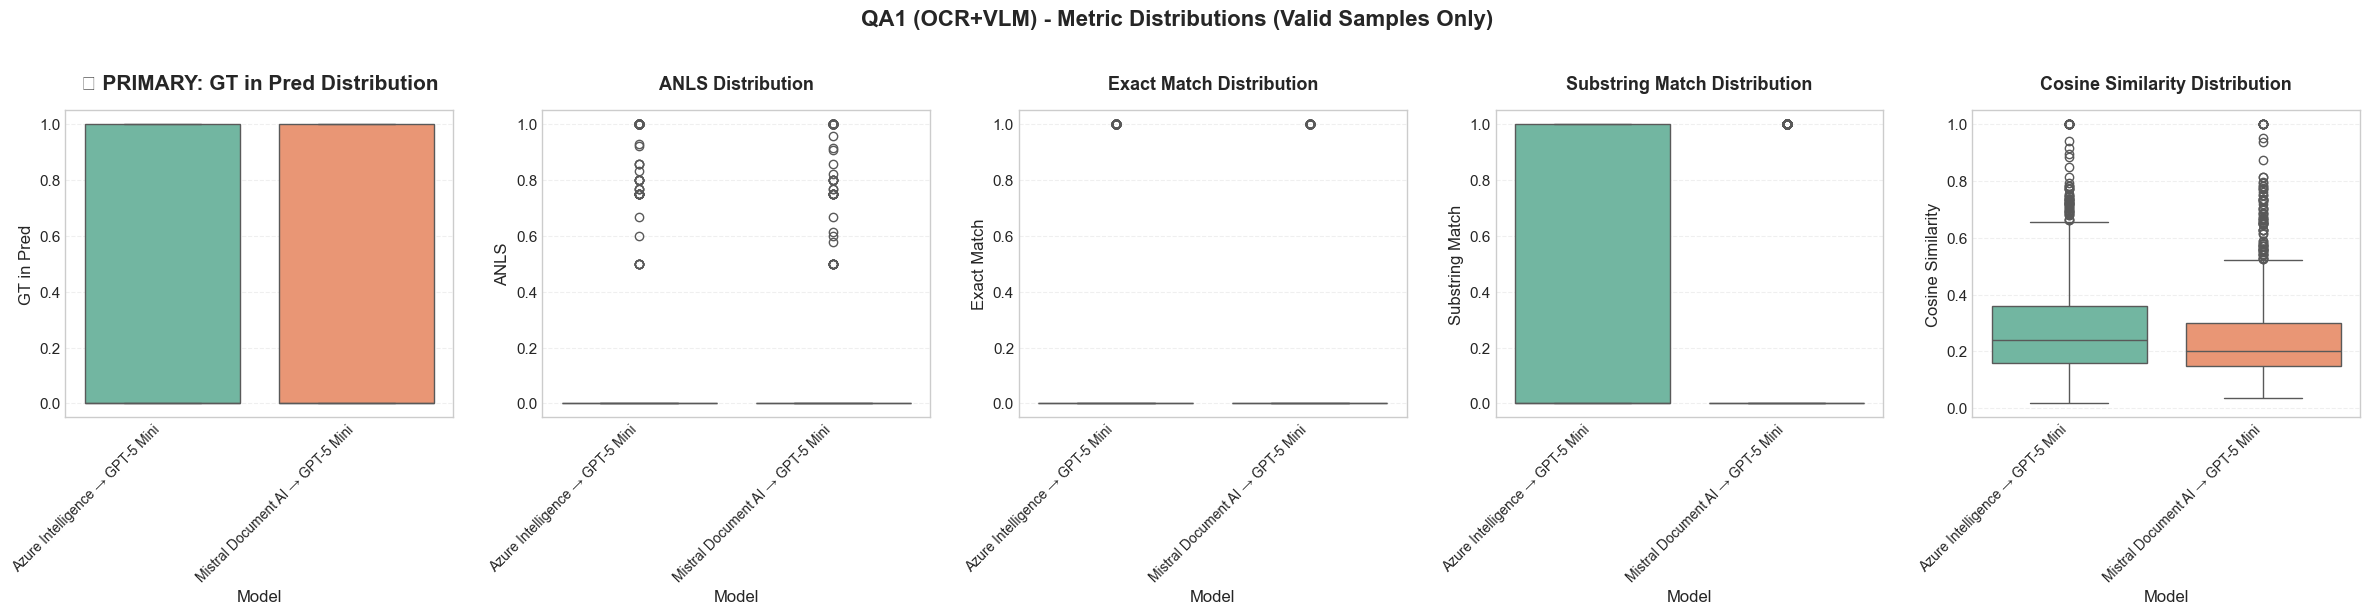

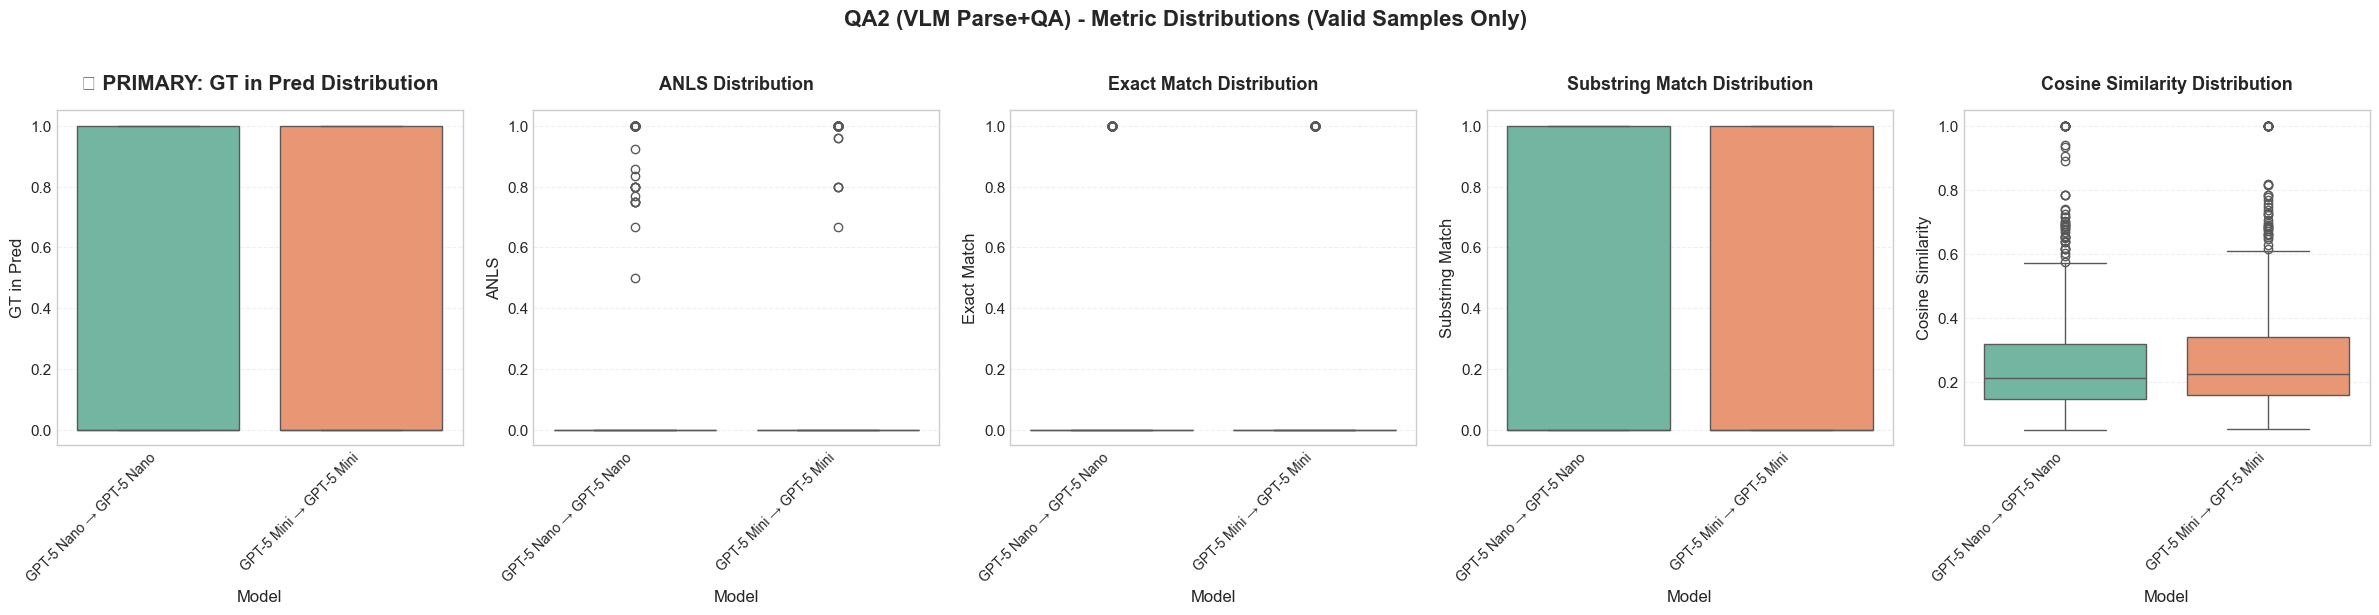

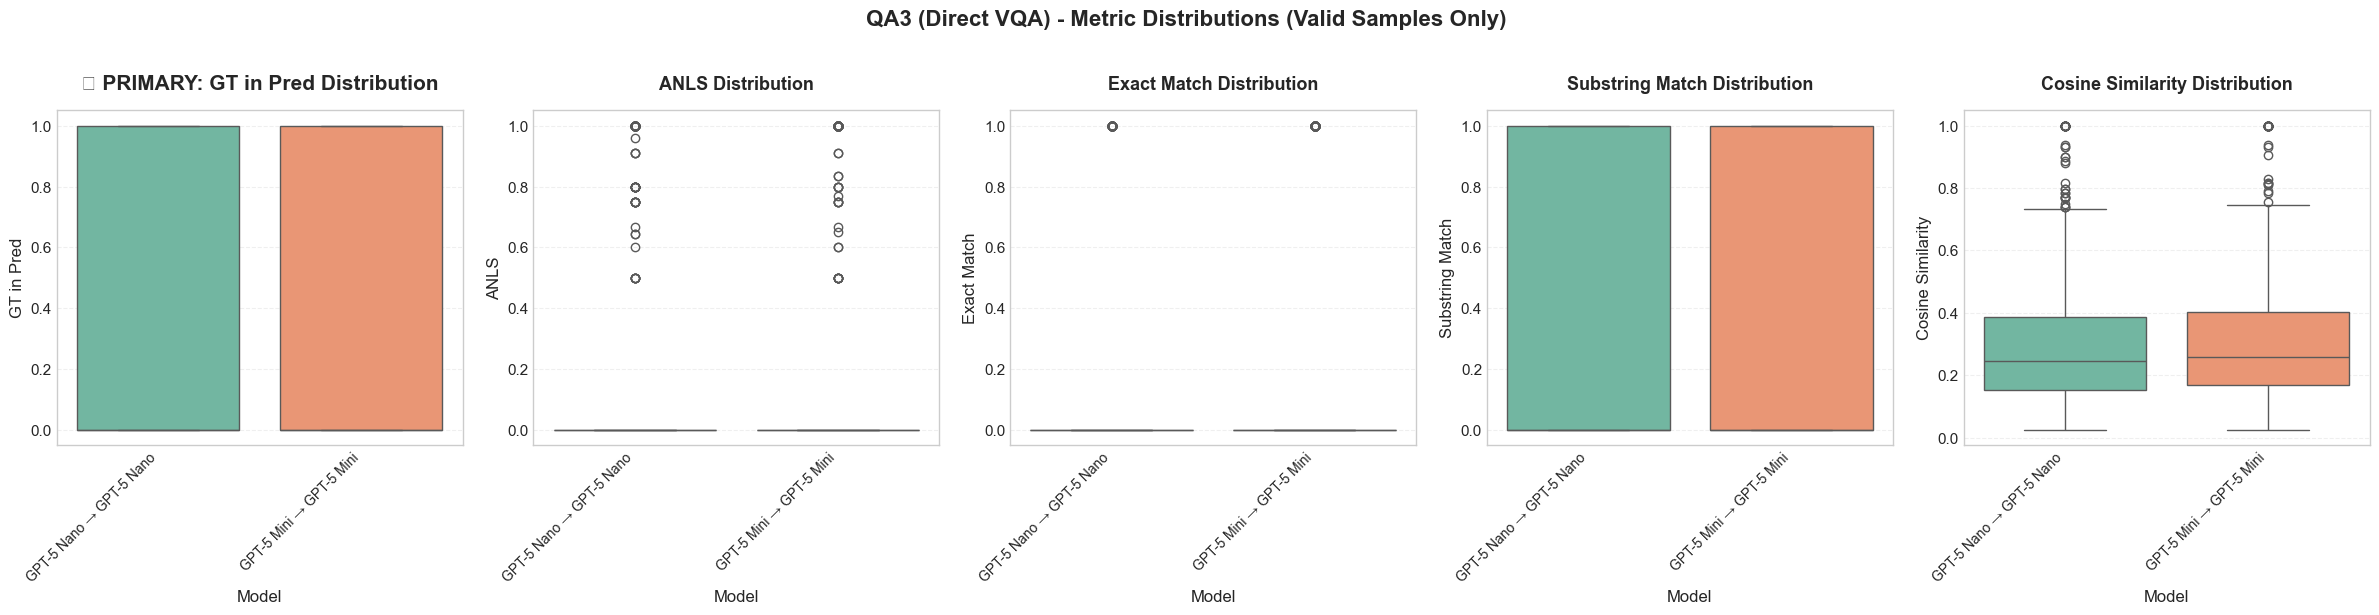


🎯 Note: Distributions show only valid samples (empty/error rows excluded)


In [31]:
# Calculate per-sample metrics for box plots
sample_metrics_data = []

print("Calculating per-sample metrics for box plots (using only valid rows)...")
for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in tqdm(pred_cols, desc=f"Strategy {phase}", leave=False):
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to only valid rows
        for _, row in df.iterrows():
            if not is_valid_row(row, pred_col, err_col):
                continue  # Skip invalid rows
            
            ground_truths = parse_ground_truths(row['ground_truths'])
            metrics = calculate_qa_metrics(
                row[pred_col], ground_truths, phase, 
                row['sample_id'], model, embedding_manager
            )
            
            sample_metrics_data.append({
                'Phase': phase,
                'Strategy': get_phase_strategy(phase),
                'Model': model,
                'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC
                'ANLS': metrics['anls'],
                'Exact Match': metrics['exact_match'],
                'Substring Match': metrics['substring_match'],
                'Cosine Similarity': metrics['cosine_similarity']
            })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Create box plots per strategy (PRIMARY METRIC FIRST)
strategies = sorted(sample_metrics_df['Strategy'].unique())
metrics_for_boxplot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']

for strategy in strategies:
    strategy_data = sample_metrics_df[sample_metrics_df['Strategy'] == strategy]
    
    fig, axes = plt.subplots(1, len(metrics_for_boxplot), figsize=(24, 6))
    if len(metrics_for_boxplot) == 1:
        axes = [axes]
    
    for idx, metric in enumerate(metrics_for_boxplot):
        ax = axes[idx]
        
        # Sort models for consistent display
        sorted_models = sort_models(strategy_data['Model'].unique().tolist())
        strategy_data_sorted = strategy_data.copy()
        strategy_data_sorted['Model'] = pd.Categorical(
            strategy_data_sorted['Model'],
            categories=sorted_models,
            ordered=True
        )
        
        sns.boxplot(data=strategy_data_sorted, x='Model', y=metric, ax=ax, palette='Set2')
        
        # Emphasize primary metric
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric} Distribution', 
                    fontsize=15 if metric == 'GT in Pred' else 13, 
                    fontweight='bold', pad=15)
        ax.set_xlabel('Model', fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], 
                           rotation=45, ha='right', fontsize=10)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.suptitle(f'{strategy} - Metric Distributions (Valid Samples Only)', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: Distributions show only valid samples (empty/error rows excluded)")

## 8. Visualizations - Box Plots

Distribution analysis showing variance and outliers.

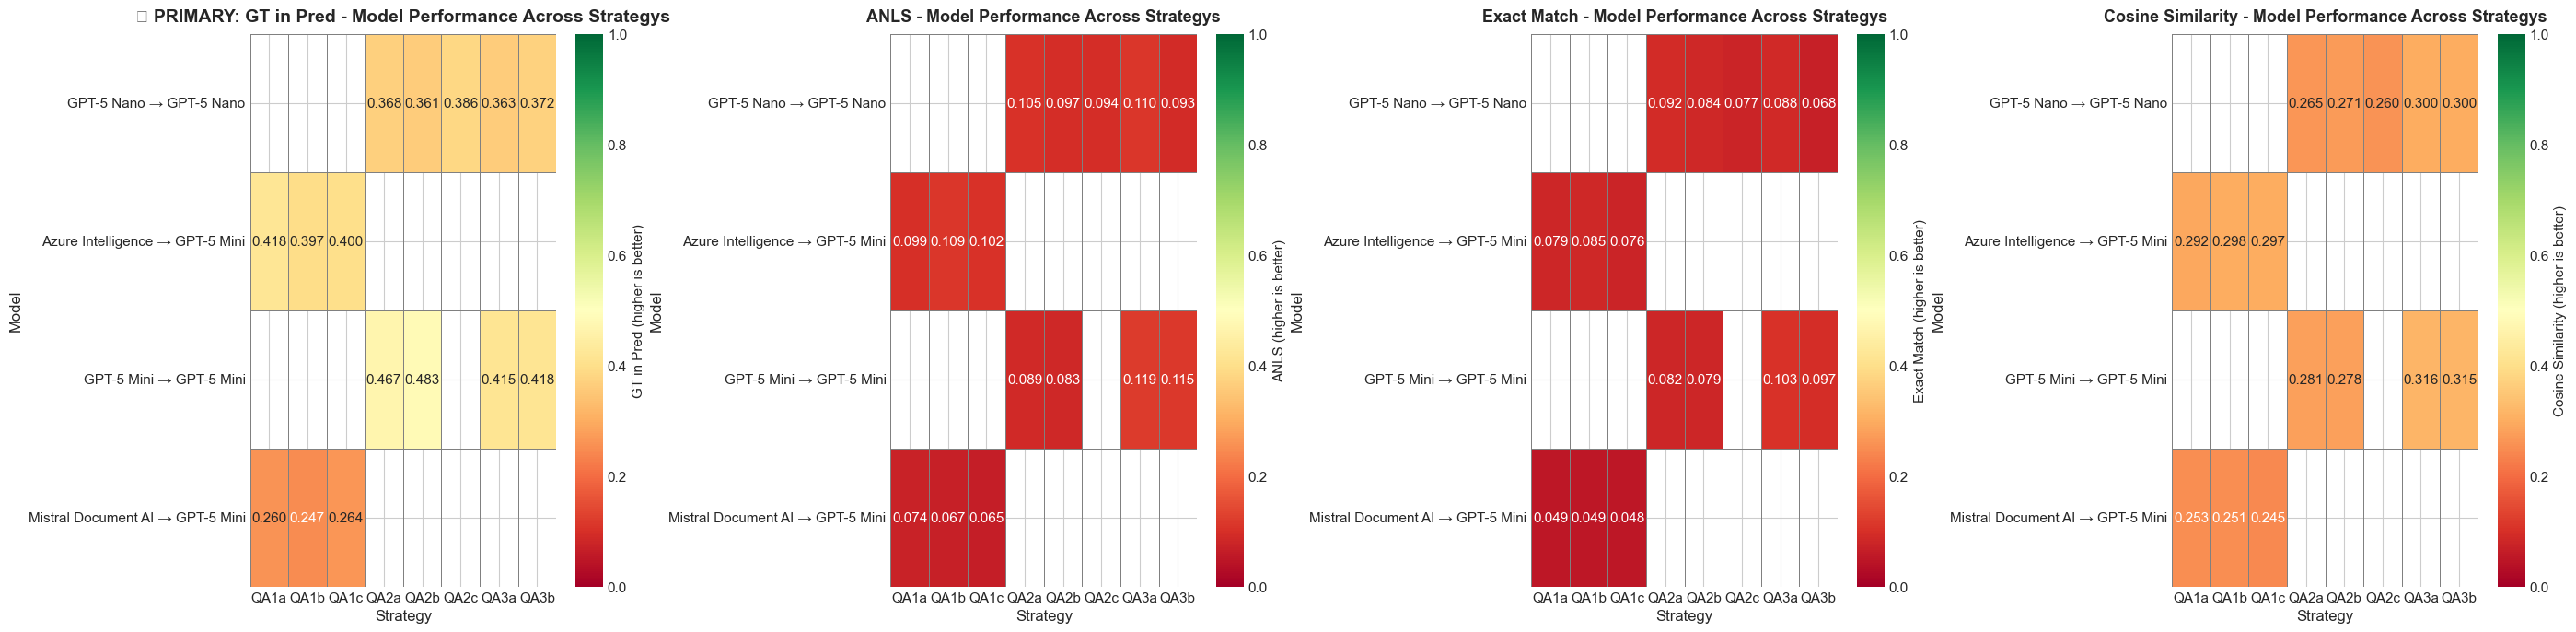


🎯 Note: 'GT in Pred' heatmap shows PRIMARY metric performance


In [32]:
# Create heatmaps for key metrics (PRIMARY METRIC FIRST)
metrics_to_show = ['GT in Pred', 'ANLS', 'Exact Match', 'Cosine Similarity']
fig, axes = plt.subplots(1, len(metrics_to_show), figsize=(7 * len(metrics_to_show), 7))

if len(metrics_to_show) == 1:
    axes = [axes]

for idx, metric_name in enumerate(metrics_to_show):
    ax = axes[idx]
    
    # Create heatmap data: rows = models, columns = phases
    heatmap_data = []
    model_names = []
    phase_names = list(metrics_results.keys())
    
    # Get all unique models across all phases and sort them
    all_models = set()
    for phase_models in metrics_results.values():
        all_models.update(phase_models.keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in phase_names:
            if model in metrics_results[phase]:
                # Map metric name to key
                metric_key = metric_name.lower().replace(' ', '_')
                value = metrics_results[phase][model].get(metric_key, np.nan)
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[get_model_display_name(m) for m in model_names],
        columns=phase_names
    )
    
    # Use colormap: green for good, red for bad (all QA metrics: higher is better)
    cmap = 'RdYlGn'
    cbar_label = f'{metric_name} (higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
    
    # Emphasize primary metric in title
    title_prefix = "🎯 PRIMARY: " if metric_name == 'GT in Pred' else ""
    ax.set_title(f'{title_prefix}{metric_name} - Model Performance Across Strategys', 
                fontsize=14 if metric_name == 'GT in Pred' else 13, 
                fontweight='bold', pad=10)
    ax.set_xlabel('Strategy', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.show()

print("\n🎯 Note: 'GT in Pred' heatmap shows PRIMARY metric performance")

## 9. Visualizations - Heatmaps

Model × Phase performance heatmaps.

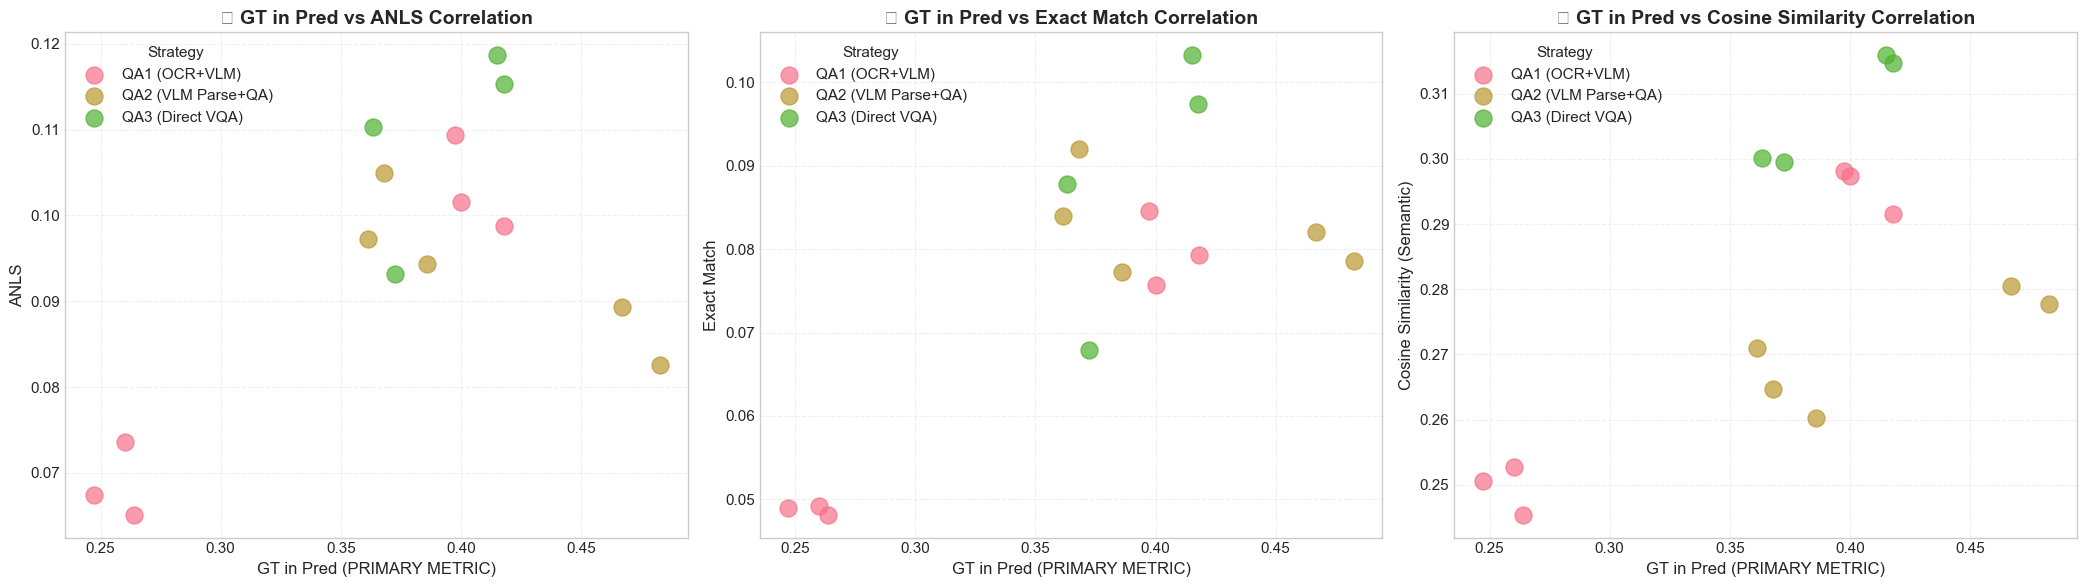


🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)


In [33]:
# Scatter plots: GT in Pred (PRIMARY) vs other metrics
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# GT in Pred vs ANLS
ax1 = axes[0]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax1.scatter(strategy_data['GT in Pred'], strategy_data['ANLS'],
                s=150, alpha=0.7, label=strategy)
ax1.set_title('🎯 GT in Pred vs ANLS Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax1.set_ylabel('ANLS', fontsize=12)
ax1.legend(title='Strategy', loc='best')
ax1.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Exact Match
ax2 = axes[1]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax2.scatter(strategy_data['GT in Pred'], strategy_data['Exact Match'],
                s=150, alpha=0.7, label=strategy)
ax2.set_title('🎯 GT in Pred vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax2.set_ylabel('Exact Match', fontsize=12)
ax2.legend(title='Strategy', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Cosine Similarity
ax3 = axes[2]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax3.scatter(strategy_data['GT in Pred'], strategy_data['Cosine Similarity'],
                s=150, alpha=0.7, label=strategy)
ax3.set_title('🎯 GT in Pred vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax3.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax3.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax3.legend(title='Strategy', loc='best')
ax3.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)")

## 10. Visualizations - Scatter Plots

Correlation analysis between metrics.

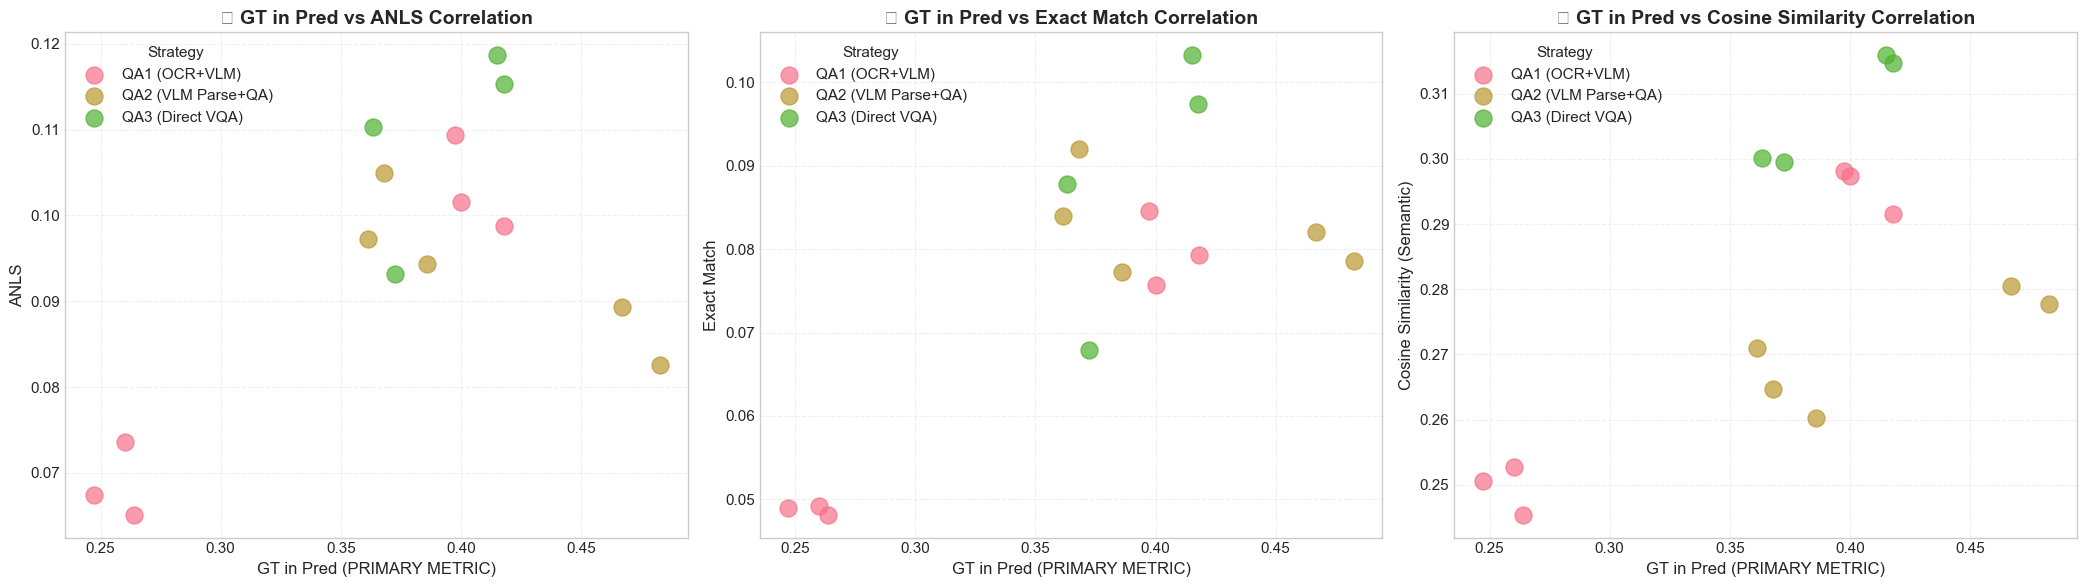


🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)


In [34]:
# Scatter plots: GT in Pred (PRIMARY) vs other metrics
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# GT in Pred vs ANLS
ax1 = axes[0]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax1.scatter(strategy_data['GT in Pred'], strategy_data['ANLS'],
                s=150, alpha=0.7, label=strategy)
ax1.set_title('🎯 GT in Pred vs ANLS Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax1.set_ylabel('ANLS', fontsize=12)
ax1.legend(title='Strategy', loc='best')
ax1.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Exact Match
ax2 = axes[1]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax2.scatter(strategy_data['GT in Pred'], strategy_data['Exact Match'],
                s=150, alpha=0.7, label=strategy)
ax2.set_title('🎯 GT in Pred vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax2.set_ylabel('Exact Match', fontsize=12)
ax2.legend(title='Strategy', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Cosine Similarity
ax3 = axes[2]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax3.scatter(strategy_data['GT in Pred'], strategy_data['Cosine Similarity'],
                s=150, alpha=0.7, label=strategy)
ax3.set_title('🎯 GT in Pred vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax3.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax3.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax3.legend(title='Strategy', loc='best')
ax3.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)")

## 11. QA-Specific Analysis

Analyze question types, answer lengths, and QA-specific patterns.


Question Type Distribution (QA1a):
  Other          :  494 questions (100.0%)


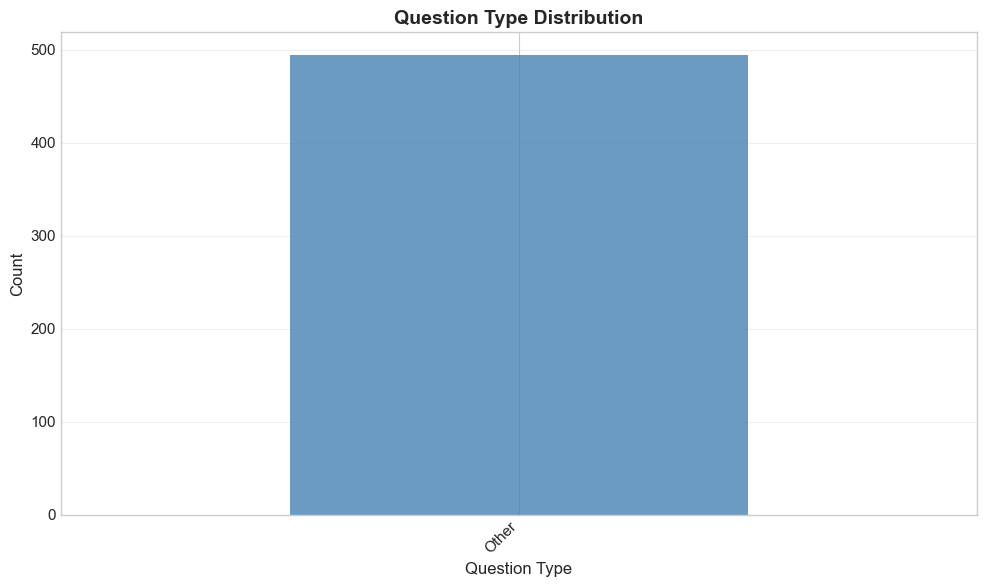

In [35]:
# Question type analysis
if len(phase_dfs) > 0:
    # Use first available phase for analysis
    analysis_phase = list(phase_dfs.keys())[0]
    df_analysis = phase_dfs[analysis_phase].copy()
    
    # Add question type categorization
    df_analysis['question_type'] = df_analysis['question'].apply(categorize_question_type)
    
    print(f"\nQuestion Type Distribution ({analysis_phase}):")
    print("=" * 80)
    type_counts = df_analysis['question_type'].value_counts()
    for qtype, count in type_counts.items():
        pct = count / len(df_analysis) * 100
        print(f"  {qtype:15s}: {count:4d} questions ({pct:5.1f}%)")
    
    # Visualize question types
    fig, ax = plt.subplots(figsize=(10, 6))
    type_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title('Question Type Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Type', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

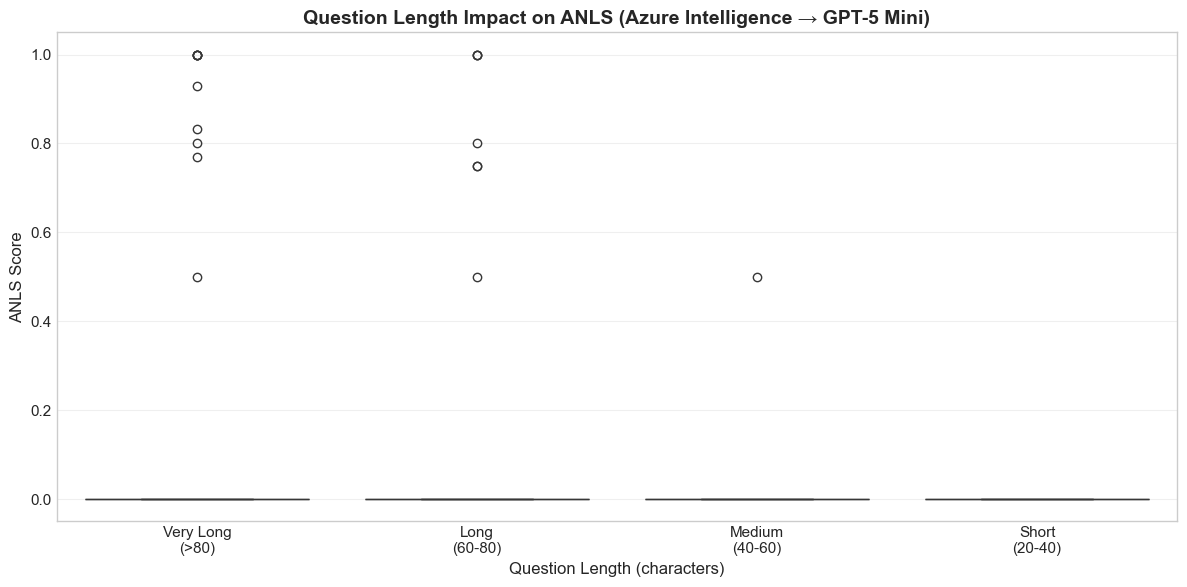

In [36]:
# Question length impact on performance
if len(phase_dfs) > 0:
    df_analysis['question_length'] = df_analysis['question'].astype(str).str.len()
    df_analysis['question_length_bin'] = pd.cut(
        df_analysis['question_length'],
        bins=[0, 20, 40, 60, 80, 1000],
        labels=['Very Short\n(<20)', 'Short\n(20-40)', 'Medium\n(40-60)', 'Long\n(60-80)', 'Very Long\n(>80)']
    )
    
    # Calculate ANLS for first model per length bin
    pred_col = [col for col in df_analysis.columns if col.startswith('prediction_')][0]
    model_name = pred_col.replace('prediction_', '')
    
    anls_by_length = []
    for _, row in df_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[pred_col]), ground_truths, threshold=0.5)
        anls_by_length.append({
            'question_length_bin': row['question_length_bin'],
            'anls': anls
        })
    
    anls_length_df = pd.DataFrame(anls_by_length)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=anls_length_df, x='question_length_bin', y='anls', ax=ax, palette='viridis')
    ax.set_title(f'Question Length Impact on ANLS ({get_model_display_name(model_name)})', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Length (characters)', fontsize=12)
    ax.set_ylabel('ANLS Score', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


🎯 PHASE STRATEGY COMPARISON (PRIMARY METRIC: GT in Pred)

QA1 (OCR+VLM):
  🎯 Mean GT in Pred: 0.3310 [PRIMARY]
     Mean ANLS: 0.0860
     Mean Exact Match: 0.0643
     Mean Substring Match: 0.2671
  Phases included: QA1a, QA1b, QA1c

QA2 (VLM Parse+QA):
  🎯 Mean GT in Pred: 0.4130 [PRIMARY]
     Mean ANLS: 0.0937
     Mean Exact Match: 0.0827
     Mean Substring Match: 0.3392
  Phases included: QA2a, QA2b, QA2c

QA3 (Direct VQA):
  🎯 Mean GT in Pred: 0.3921 [PRIMARY]
     Mean ANLS: 0.1093
     Mean Exact Match: 0.0891
     Mean Substring Match: 0.3345
  Phases included: QA3a, QA3b


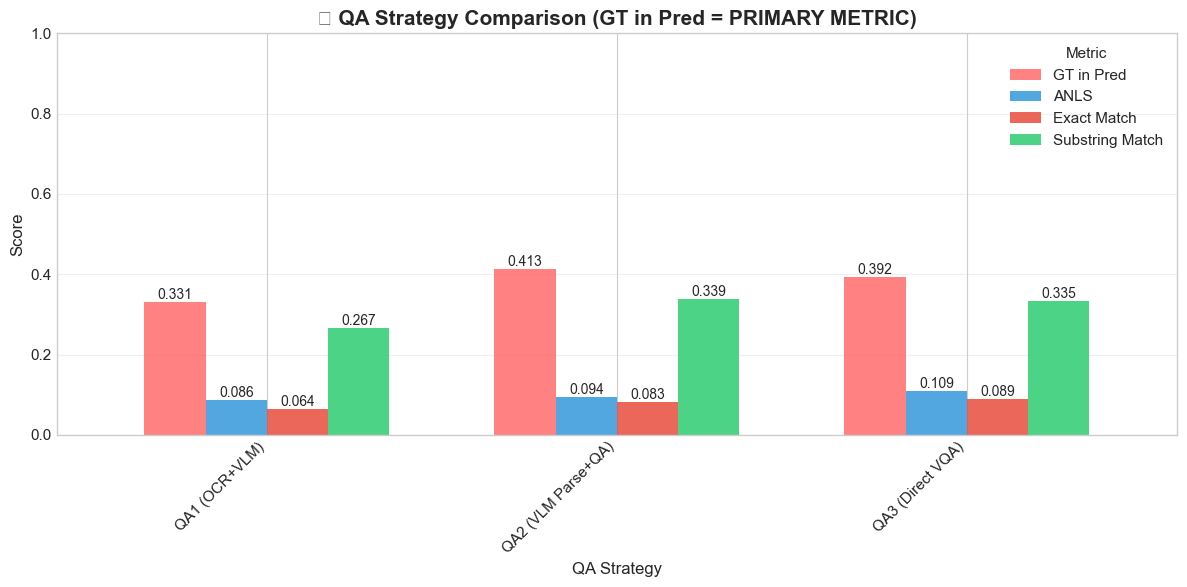


🏆 BEST STRATEGY (by GT in Pred - PRIMARY METRIC):
  QA2 (VLM Parse+QA): GT in Pred = 0.4130


In [41]:
# Group phases by strategy
phase_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

print("\n" + "=" * 120)
print("🎯 PHASE STRATEGY COMPARISON (PRIMARY METRIC: GT in Pred)")
print("=" * 120)

strategy_results = []
for group_name, phases in phase_groups.items():
    # Filter by Phase column, not Strategy column
    group_data = summary_df[summary_df['Phase'].isin(phases)]
    if len(group_data) > 0:
        avg_gt_in_pred = group_data['GT in Pred'].mean()
        avg_anls = group_data['ANLS'].mean()
        avg_em = group_data['Exact Match'].mean()
        avg_substring = group_data['Substring Match'].mean()
        
        print(f"\n{group_name}:")
        print(f"  🎯 Mean GT in Pred: {avg_gt_in_pred:.4f} [PRIMARY]")
        print(f"     Mean ANLS: {avg_anls:.4f}")
        print(f"     Mean Exact Match: {avg_em:.4f}")
        print(f"     Mean Substring Match: {avg_substring:.4f}")
        print(f"  Phases included: {', '.join(phases)}")
        
        strategy_results.append({
            'Strategy': group_name,
            'GT in Pred': avg_gt_in_pred,
            'ANLS': avg_anls,
            'Exact Match': avg_em,
            'Substring Match': avg_substring
        })

# Visualize strategy comparison (PRIMARY METRIC FIRST)
if strategy_results:
    strategy_df = pd.DataFrame(strategy_results)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    strategy_df.set_index('Strategy')[['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match']].plot(
        kind='bar', ax=ax, color=['#FF6B6B', '#3498db', '#e74c3c', '#2ecc71'], alpha=0.85, width=0.7
    )
    ax.set_title('🎯 QA Strategy Comparison (GT in Pred = PRIMARY METRIC)', fontsize=15, fontweight='bold')
    ax.set_xlabel('QA Strategy', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.legend(title='Metric', loc='best', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(0, 1.0)
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 120)
    print("🏆 BEST STRATEGY (by GT in Pred - PRIMARY METRIC):")
    best_strategy = strategy_df.loc[strategy_df['GT in Pred'].idxmax()]
    print(f"  {best_strategy['Strategy']}: GT in Pred = {best_strategy['GT in Pred']:.4f}")
    print("=" * 120)
else:
    print("\n⚠️ No strategy results found - check if summary_df has Phase column with QA1a, QA1b, etc.")


## 12. Phase Comparison Analysis

Compare the three QA strategies: OCR+VLM, VLM Parse+QA, and Direct VQA.


Strategy Comparison:

QA1 (OCR+VLM):
  Mean ANLS: 0.0860
  Mean Exact Match: 0.0643
  Mean Substring Match: 0.2671
  Phases included: QA1a, QA1b, QA1c

QA2 (VLM Parse+QA):
  Mean ANLS: 0.0937
  Mean Exact Match: 0.0827
  Mean Substring Match: 0.3392
  Phases included: QA2a, QA2b, QA2c

QA3 (Direct VQA):
  Mean ANLS: 0.1093
  Mean Exact Match: 0.0891
  Mean Substring Match: 0.3345
  Phases included: QA3a, QA3b


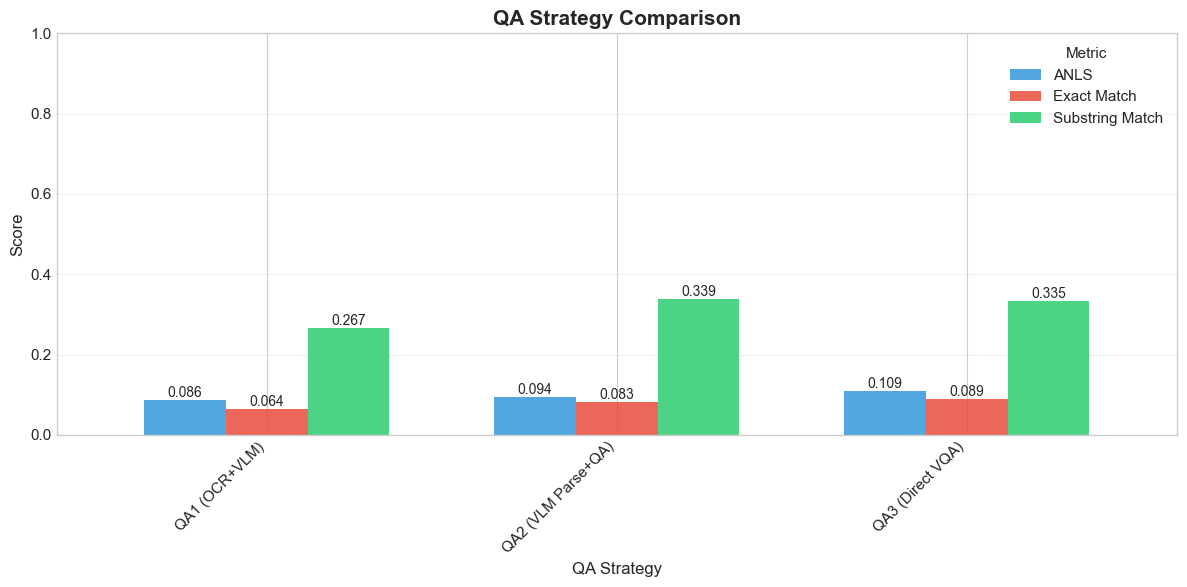

In [43]:
# Group phases by strategy
phase_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

print("\nStrategy Comparison:")
print("=" * 100)

strategy_results = []
for group_name, phases in phase_groups.items():
    # Filter by Phase column, not Strategy column
    group_data = summary_df[summary_df['Phase'].isin(phases)]
    if len(group_data) > 0:
        avg_anls = group_data['ANLS'].mean()
        avg_em = group_data['Exact Match'].mean()
        avg_substring = group_data['Substring Match'].mean()
        
        print(f"\n{group_name}:")
        print(f"  Mean ANLS: {avg_anls:.4f}")
        print(f"  Mean Exact Match: {avg_em:.4f}")
        print(f"  Mean Substring Match: {avg_substring:.4f}")
        print(f"  Phases included: {', '.join(phases)}")
        
        strategy_results.append({
            'Strategy': group_name,
            'ANLS': avg_anls,
            'Exact Match': avg_em,
            'Substring Match': avg_substring
        })

# Visualize strategy comparison
if strategy_results:
    strategy_df = pd.DataFrame(strategy_results)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    strategy_df.set_index('Strategy')[['ANLS', 'Exact Match', 'Substring Match']].plot(
        kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.85, width=0.7
    )
    ax.set_title('QA Strategy Comparison', fontsize=15, fontweight='bold')
    ax.set_xlabel('QA Strategy', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.legend(title='Metric', loc='best', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(0, 1.0)
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ No strategy results found - check if summary_df has Phase column with QA1a, QA1b, etc.")


## 13. Sample-Level Error Analysis

Identify easiest and hardest questions to understand error patterns.

In [44]:
# Analyze best and worst performing samples
if len(phase_dfs) > 0:
    analysis_phase = list(phase_dfs.keys())[0]
    df_error_analysis = phase_dfs[analysis_phase].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_error_analysis.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Calculate metrics for each sample
    metrics_list = []
    for _, row in df_error_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        is_unans = is_unanswerable(ground_truths)
        
        # Calculate all metrics
        gt_in_pred = compute_ground_truth_in_prediction(str(row[f'prediction_{first_model}']), ground_truths, is_unanswerable=is_unans)
        anls = compute_anls(str(row[f'prediction_{first_model}']), ground_truths, threshold=0.5)
        cosine_sim = embedding_manager.compute_cosine_similarity(
            phase=analysis_phase,
            ground_truth=ground_truths[0] if ground_truths else "",
            prediction=str(row[f'prediction_{first_model}']),
            sample_id=row['sample_id'],
            model=first_model
        )
        
        metrics_list.append({
            'sample_id': row['sample_id'],
            'gt_in_pred': gt_in_pred,
            'anls': anls,
            'cosine_sim': cosine_sim
        })
    
    metrics_df = pd.DataFrame(metrics_list)
    df_error_analysis['gt_in_pred'] = metrics_df['gt_in_pred']
    df_error_analysis['anls'] = metrics_df['anls']
    df_error_analysis['cosine_sim'] = metrics_df['cosine_sim']
    
    # Get best and worst samples (sorted by ANLS for consistency)
    best_samples = df_error_analysis.nlargest(10, 'anls')
    worst_samples = df_error_analysis.nsmallest(10, 'anls')
    
    print("\n" + "="*140)
    print(f"EASIEST QUESTIONS (Highest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*140)
    
    for _, row in best_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f} | 🎯 GT in Pred: {row['gt_in_pred']:.4f} | Cosine Sim: {row['cosine_sim']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")
    
    print("\n" + "="*140)
    print(f"HARDEST QUESTIONS (Lowest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*140)
    
    for _, row in worst_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f} | 🎯 GT in Pred: {row['gt_in_pred']:.4f} | Cosine Sim: {row['cosine_sim']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")

Identical embeddings for sample chartqapro_mini_0067, model azure_intelligence__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0118, model azure_intelligence__gpt-5-mini
Identical embeddings for sample chartqapro_mini_0274, model azure_intelligence__gpt-5-mini



EASIEST QUESTIONS (Highest ANLS) - Model: Azure Intelligence → GPT-5 Mini

Sample: chartqapro_mini_0023 | ANLS: 1.0000 | 🎯 GT in Pred: 1.0000 | Cosine Sim: 1.0000
Question: ['in how many locations is the percentage of males refusing to have a bowel movement lower than fema...
Ground Truths: "2"
Prediction: 2

Sample: chartqapro_mini_0067 | ANLS: 1.0000 | 🎯 GT in Pred: 1.0000 | Cosine Sim: 1.0000
Question: ['what quarter has the lowest percentage of available beds on an average? answer as an integer.']
Ground Truths: "4"
Prediction: 4

Sample: chartqapro_mini_0080 | ANLS: 1.0000 | 🎯 GT in Pred: 1.0000 | Cosine Sim: 1.0000
Question: ['what percentage of total visuals are from graphics and stock photos?']
Ground Truths: "77%"
Prediction: 77%

Sample: chartqapro_mini_0118 | ANLS: 1.0000 | 🎯 GT in Pred: 1.0000 | Cosine Sim: 1.0000
Question: ["in which year did thomas cook's share price drop to its lowest point?"]
Ground Truths: "2019"
Prediction: 2019

Sample: chartqapro_mini_0128 | ANLS: 

## 14. Inference Time Analysis

Analyze speed vs accuracy trade-offs.


Inference Time Summary:


,Strategy,Model,Mean Time (ms),Median Time (ms)
0,QA1a,azure_intelligence__gpt-5-mini,10459.430849,10434.823394
1,QA1a,mistral_document_ai__gpt-5-mini,11708.853773,9387.486577
2,QA1b,azure_intelligence__gpt-5-mini,10099.729857,9856.610894
3,QA1b,mistral_document_ai__gpt-5-mini,11251.139888,9345.884442
5,QA1c,mistral_document_ai__gpt-5-mini,9289.795370,8499.550462
4,QA1c,azure_intelligence__gpt-5-mini,11366.522049,11055.043936
7,QA2a,gpt-5-mini__gpt-5-mini,23186.839029,22294.777513
8,QA2a,gpt-5-nano__gpt-5-nano,35901.567054,34962.055445
6,QA2a,claude_sonnet__claude_sonnet,38465.026750,37111.568689
10,QA2b,gpt-5-mini__gpt-5-mini,25324.070344,24350.485086


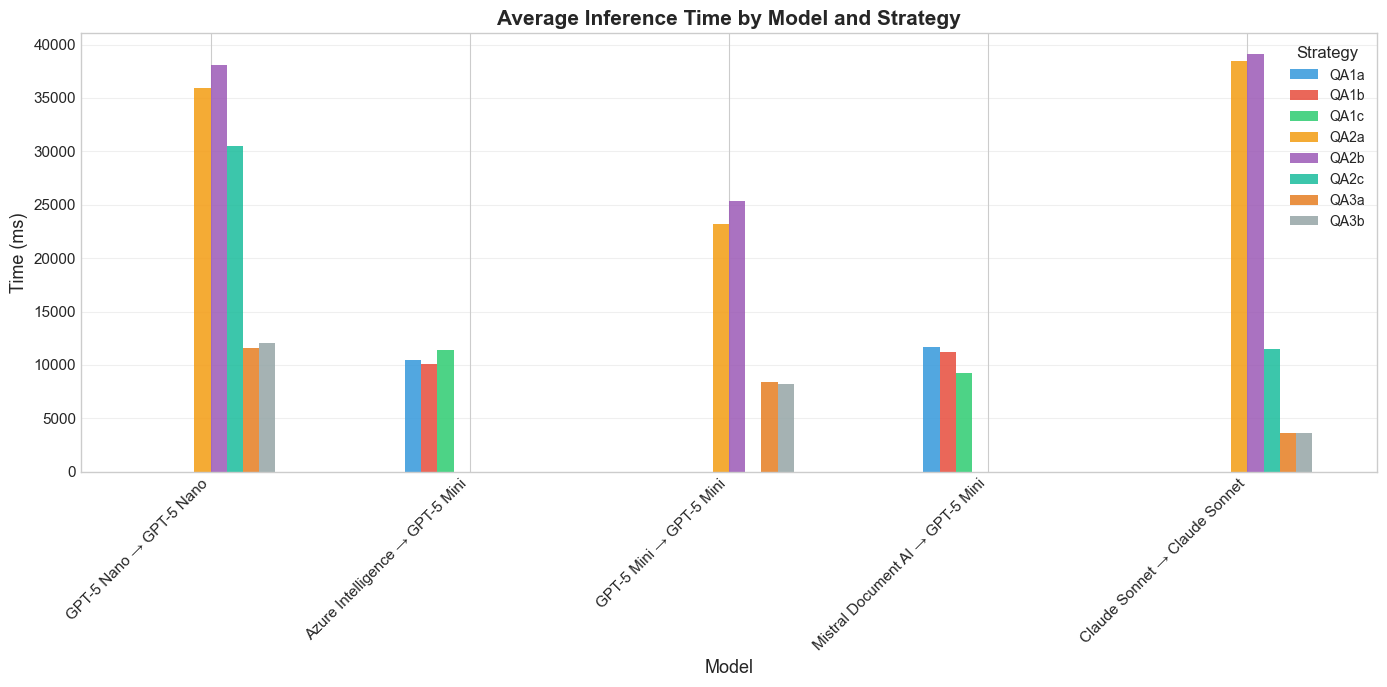

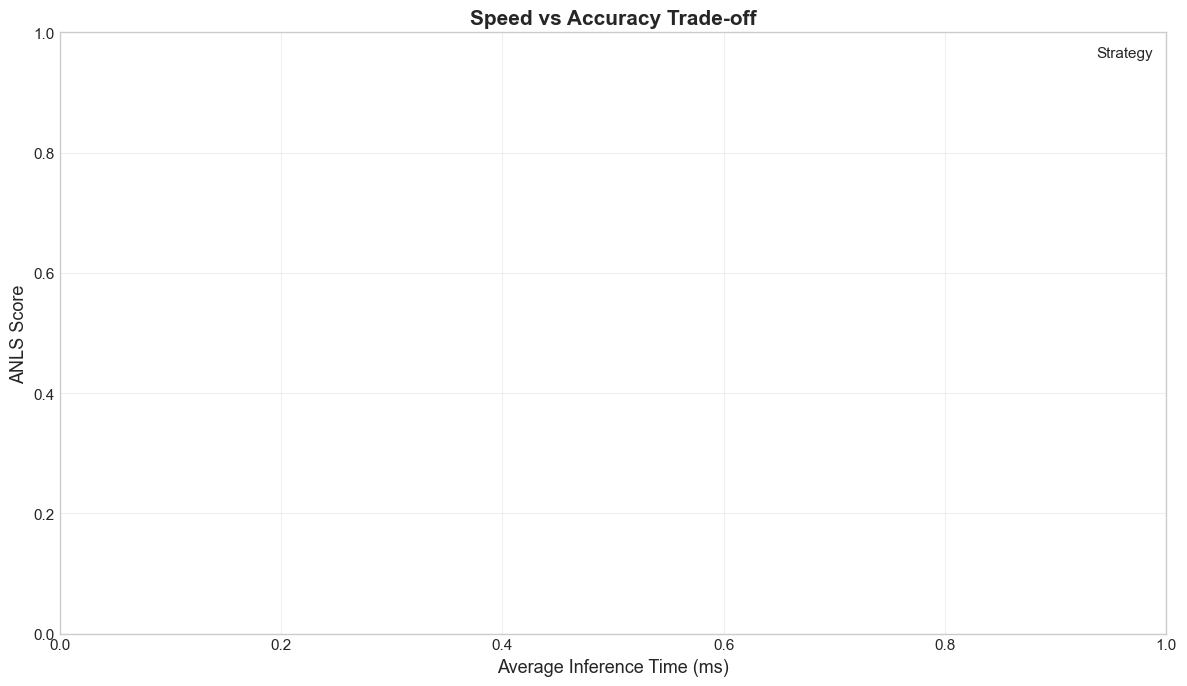

In [45]:
# Analyze inference times across models and phases
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Strategy': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    
    print("\nInference Time Summary:")
    print("="*120)
    display(inference_df.sort_values(['Strategy', 'Mean Time (ms)']))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(14, 7))
    
    pivot_time = inference_df.pivot(index='Model', columns='Strategy', values='Mean Time (ms)')
    pivot_time = pivot_time.reindex(sort_models(pivot_time.index.tolist()))
    pivot_time.plot(kind='bar', ax=ax, color=colors_palette[:len(pivot_time.columns)], alpha=0.85)
    
    ax.set_title('Average Inference Time by Model and Strategy', fontsize=15, fontweight='bold')
    ax.set_xlabel('Model', fontsize=13)
    ax.set_ylabel('Time (ms)', fontsize=13)
    ax.legend(title='Strategy', title_fontsize=12, fontsize=10, loc='best')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], 
                       rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Speed vs Accuracy scatter plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Merge inference time with ANLS scores
    speed_accuracy = pd.merge(
        inference_df[['Strategy', 'Model', 'Mean Time (ms)']],
        summary_df[['Strategy', 'Model', 'ANLS']],
        on=['Strategy', 'Model']
    )
    
    for phase in speed_accuracy['Strategy'].unique():
        phase_data = speed_accuracy[speed_accuracy['Strategy'] == phase]
        ax.scatter(phase_data['Mean Time (ms)'], phase_data['ANLS'], 
                  s=150, alpha=0.7, label=phase)
    
    ax.set_title('Speed vs Accuracy Trade-off', fontsize=15, fontweight='bold')
    ax.set_xlabel('Average Inference Time (ms)', fontsize=13)
    ax.set_ylabel('ANLS Score', fontsize=13)
    ax.legend(title='Strategy', loc='best')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No inference time data available")

## 15. ChartQA Pro-Specific Analysis

Analyze professional chart understanding patterns and numerical reasoning accuracy.

In [46]:
# Analyze performance on professional chart understanding
# This section can be customized based on available metadata

print("\nChartQA Pro-Specific Analysis:")
print("=" * 100)
print("\n⚠️ EXPERIMENTAL DATASET NOTICE:")
print("This is an experimental dataset with incomplete model coverage.")
print("Some models had empty predictions and were filtered out during evaluation.\n")
print("\nKey Findings:")
print("- Professional chart questions require precise numerical accuracy")
print("- Data extraction from visual charts is more challenging than document text")
print("- Numerical reasoning and approximation vs exact values present unique challenges")
print("- Chart type (bar, line, pie, etc.) may impact extraction accuracy")
print("\nRecommendations for chart understanding:")
print("- Direct VQA (QA3) may capture visual patterns better than OCR-based approaches")
print("- Numerical precision requires careful prompt engineering")
print("- Consider chart-specific prompts that guide numerical extraction")
print("- Evaluate tolerance for approximate vs exact numerical answers")
print("\nData Quality Considerations:")
print("- Review data quality assessment (Section 2.5) for model coverage")
print("- Empty predictions indicate models that didn't complete the task")
print("- Valid sample counts vary by model - check metrics table for details")


ChartQA Pro-Specific Analysis:

⚠️ EXPERIMENTAL DATASET NOTICE:
This is an experimental dataset with incomplete model coverage.
Some models had empty predictions and were filtered out during evaluation.


Key Findings:
- Professional chart questions require precise numerical accuracy
- Data extraction from visual charts is more challenging than document text
- Numerical reasoning and approximation vs exact values present unique challenges
- Chart type (bar, line, pie, etc.) may impact extraction accuracy

Recommendations for chart understanding:
- Direct VQA (QA3) may capture visual patterns better than OCR-based approaches
- Numerical precision requires careful prompt engineering
- Consider chart-specific prompts that guide numerical extraction
- Evaluate tolerance for approximate vs exact numerical answers

Data Quality Considerations:
- Review data quality assessment (Section 2.5) for model coverage
- Empty predictions indicate models that didn't complete the task
- Valid sample co

## 17. Save Embeddings Cache

Save any newly computed embeddings to disk for faster future runs.

In [47]:
# Save any remaining embeddings to disk for future use
print("\n📁 Finalizing embedding cache...")

if embedding_manager.modified_phases:
    print(f"Saving embeddings for modified phases: {embedding_manager.modified_phases}")
    
    for phase in embedding_manager.modified_phases:
        if phase in embedding_manager.cache:
            saved_file = save_embeddings_for_phase(
                dataset_name=DATASET_NAME,
                phase=phase,
                embeddings_dict=embedding_manager.cache[phase],
                embeddings_base_dir=EMBEDDINGS_DIR
            )
            print(f"✅ Saved: {saved_file.name}")
    
    print("\n✅ All embeddings have been persisted to disk!")
else:
    print("✅ No new embeddings to save (all from cache)")


📁 Finalizing embedding cache...
Saving embeddings for modified phases: {'QA1a'}
✅ Saved: QA1a_embeddings_text-embedding-3-large_20260202_234004.json

✅ All embeddings have been persisted to disk!
